In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Early Data EDA, only using mimic_iv data

In [2]:
csv_file_path = '/content/mimic_iii_stats2.csv'

# Read the CSV file into a DataFrame

df = pd.read_csv(csv_file_path)

df_full = pd.read_csv(csv_file_path)    #needed for later

In [3]:
df.shape

(666, 227)

In [4]:
columns = df.columns

#printing all columns of dataframe
for column in columns:
  print(column)

SUBJECT_ID
HADM_ID
sex
age
race
ADMITTIME
DISCHTIME
ADMISSION_TYPE
ADMISSION_LOCATION
DISCHARGE_LOCATION
INSURANCE
HOSPITAL_EXPIRE_FLAG
date_of_death
mortality_flag
length_of_stay_hours
length_of_stay_days
myocardial_infarction
congestive_heart_failure
peripheral_vascular_disease
cerebrovascular_disease
dementia
chronic_pulmonary_disease
rheumatic_disease
peptic_ulcer_disease
diabetes
paraplegia
renal_disease
malignant_cancer
severe_liver_disease
metastatic_solid_tumor
aids
HBV
HCV
cirrhosis
liver_failure
portal_hypertension
rbc_max
rbc_min
rbc_avg
rbc_count
wbc_max
wbc_min
wbc_avg
wbc_count
hgb_max
hgb_min
hgb_avg
hgb_count
plt_max
plt_min
plt_avg
plt_count
rdw_max
rdw_min
rdw_avg
rdw_count
hct_max
hct_min
hct_avg
hct_count
aptt_max
aptt_min
aptt_avg
aptt_count
pt_max
pt_min
pt_avg
pt_count
inr_max
inr_min
inr_avg
inr_count
bicarbonate_max
bicarbonate_min
bicarbonate_avg
bicarbonate_count
lactate_max
lactate_min
lactate_avg
lactate_count
base_excess_max
base_excess_min
base_excess_avg

In [5]:
df.columns = df.columns.str.lower()

In [6]:
df.head(5)

,subject_id,hadm_id,sex,age,race,admittime,dischtime,admission_type,admission_location,discharge_location,...,bmi_avg,bmi_count,gcs_total_max,gcs_total_min,gcs_total_avg,gcs_total_count,gcs_total_stddev,lactulose_prescriptions_count,rifaximin_prescriptions_count,urine_output_total
0,69047,163230,M,58,WHITE,2192-01-10 00:21:00,2192-01-23 15:40:00,EMERGENCY,EMERGENCY ROOM ADMIT,LONG TERM CARE HOSPITAL,...,NaN,0.0,NaN,NaN,NaN,0.0,NaN,2.0,0.0,2447.0
1,85639,173055,M,49,WHITE,2138-08-01 10:15:00,2138-09-23 14:20:00,ELECTIVE,PHYS REFERRAL/NORMAL DELI,SNF,...,NaN,0.0,NaN,NaN,NaN,0.0,NaN,0.0,0.0,300.0
2,1494,191711,M,47,WHITE,2116-12-16 20:49:00,2116-12-29 18:30:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME HEALTH CARE,...,NaN,0.0,9.0,9.0,9.0,1.0,NaN,2.0,0.0,2480.0
3,5197,181082,M,55,WHITE,2150-09-04 18:49:00,2150-10-06 18:11:00,EMERGENCY,EMERGENCY ROOM ADMIT,REHAB/DISTINCT PART HOSP,...,NaN,0.0,15.0,15.0,15.0,1.0,NaN,1.0,0.0,2225.0
4,7144,122689,F,52,UNKNOWN/NOT SPECIFIED,2125-07-22 22:22:00,2125-07-29 14:00:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOSPICE-HOME,...,NaN,0.0,7.0,7.0,7.0,1.0,NaN,0.0,0.0,826.0


# Number of Patients

In [7]:
print(df['subject_id'].nunique())

589


### **589 unique patients having Hepatic Encephalopathy**

### **666 total visits to hospital**

### 1. The distribution of mortality per visit to hospital

Number of Hospital Admissions by Mortality Status:
Alive    444
Dead     222
Name: hadm_id, dtype: int64


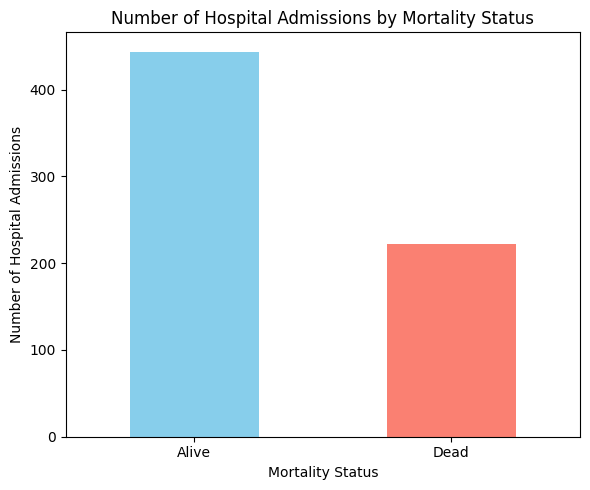

In [9]:
mortality_counts = df.groupby('mortality_flag')['hadm_id'].nunique()

# Rename index for better plotting labels
mortality_counts.index = ['Alive', 'Dead']

print("Number of Hospital Admissions by Mortality Status:")
print(mortality_counts)

plt.figure(figsize=(6, 5))
mortality_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Number of Hospital Admissions by Mortality Status')
plt.xlabel('Mortality Status')
plt.ylabel('Number of Hospital Admissions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2. The distribution of mortality per unique subject_id (patients)

Distribution of Unique Subject IDs by Mortality Status:
mortality_flag
Alive    393
Dead     217
Name: subject_id, dtype: int64


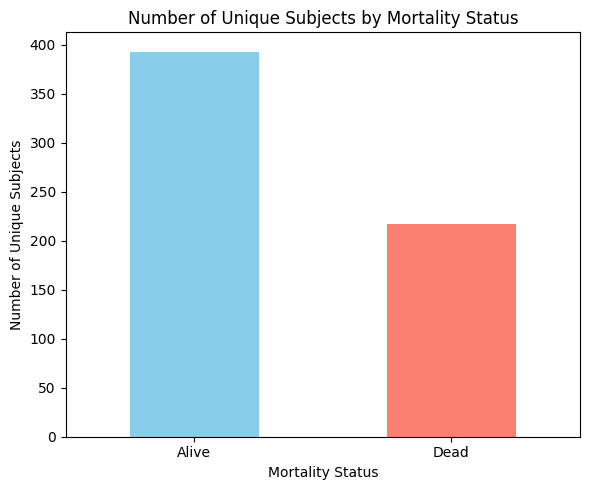

In [10]:
# Group by mortality_flag and count unique subject_id
subject_mortality_counts = df.groupby('mortality_flag')['subject_id'].nunique()

# Print the distribution
print("Distribution of Unique Subject IDs by Mortality Status:")
print(subject_mortality_counts.rename(index={0: 'Alive', 1: 'Dead'}))

# Rename index for better plotting labels
subject_mortality_counts.index = ['Alive', 'Dead']

# Create the bar chart
plt.figure(figsize=(6, 5))
subject_mortality_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Number of Unique Subjects by Mortality Status')
plt.xlabel('Mortality Status')
plt.ylabel('Number of Unique Subjects')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# **Cleaning Data and Statistical Analysis**

## First, we have some useless features, like subject_id, hadm_id. removing it.

## Also, only predicting the mortality, removing length of stay



In [11]:
columns_to_drop = ['subject_id', 'hadm_id',
                   'admittime', 'dischtime',
                   'discharge_location',
                   'date_of_death',
                   'length_of_stay_hours',
                   'length_of_stay_days',
                   'hospital_expire_flag']

df = df.drop(columns=columns_to_drop, axis=1)

## Remove the medication and urine as they can leak information

In [12]:
columns_to_drop = ['lactulose_prescriptions_count',
                   'rifaximin_prescriptions_count',
                   'urine_output_total']

df = df.drop(columns=columns_to_drop, axis=1)

## Now taking out comorbid diseases, and average of labs and vitals only.

**The Labs and Vitals are the First 24 Hours of readings taken**

In [13]:
# Comorbidity columns
comorbidity_cols = [
    'myocardial_infarction',
    'congestive_heart_failure',
    'peripheral_vascular_disease',
    'cerebrovascular_disease',
    'dementia',
    'chronic_pulmonary_disease',
    'rheumatic_disease',
    'peptic_ulcer_disease',
    'diabetes',
    'paraplegia',
    'renal_disease',
    'malignant_cancer',
    'severe_liver_disease',
    'metastatic_solid_tumor',
    'aids'
]

# All average-value columns, include both labs + vitals
avg_cols = [col for col in df.columns if col.endswith('_avg')]

# Create DataFrame
df_avg = df[comorbidity_cols + avg_cols + ['mortality_flag']].copy()

In [14]:
for col in avg_cols:
  print(col)

rbc_avg
wbc_avg
hgb_avg
plt_avg
rdw_avg
hct_avg
aptt_avg
pt_avg
inr_avg
bicarbonate_avg
lactate_avg
base_excess_avg
anion_gap_avg
chloride_avg
calcium_avg
sodium_avg
potassium_avg
glucose_avg
creatinine_avg
bun_avg
tbil_avg
albumin_avg
alt_avg
ast_avg
alp_avg
fibrinogen_avg
crp_avg
ammonia_avg
uric_acid_avg
total_cholesterol_avg
triglycerides_avg
hdl_avg
ldl_avg
dbil_avg
temperature_avg
map_avg
sbp_avg
dbp_avg
heart_rate_avg
respiratory_rate_avg
o2_avg
weight_avg
height_avg
bmi_avg
gcs_total_avg


### Now where the readings were NULL, the average is 0. Can not decide about the missing values. For that, use max readings. Where max is null, make avg_null

In [15]:
# For each average column, use its corresponding max column
# to identify missing measurements
for avg_col in avg_cols:
    max_col = avg_col.replace('_avg', '_max')

    # If max is NaN, set average to NaN
    df_avg.loc[df[max_col].isna(), avg_col] = np.nan

In [16]:
# Calculate BMI

df_avg['bmi_avg'] = df_avg['weight_avg'] / (df_avg['height_avg'] / 100) ** 2

### Missing Values Analysis

In [17]:
df_avg.shape

(666, 61)

**61 features**

**666 rows total**

In [18]:
df_avg.isnull().sum()

,0
myocardial_infarction,0
congestive_heart_failure,0
peripheral_vascular_disease,0
cerebrovascular_disease,0
dementia,0
...,...
weight_avg,280
height_avg,607
bmi_avg,607
gcs_total_avg,442


**Percentage of missing values**

In [19]:
# Calculate percentages
missing_percentage = (df_avg.isnull().sum() / len(df_avg)) * 100

# Sort in ascending order
missing_percentage_sorted = missing_percentage.sort_values()

# Print results
print("Percentage of missing values per column (ascending):")
for column, percentage in zip(missing_percentage_sorted.index, missing_percentage_sorted):
    print(f"  {column}: {percentage:.2f}%")


Percentage of missing values per column (ascending):
  myocardial_infarction: 0.00%
  congestive_heart_failure: 0.00%
  peripheral_vascular_disease: 0.00%
  cerebrovascular_disease: 0.00%
  dementia: 0.00%
  chronic_pulmonary_disease: 0.00%
  rheumatic_disease: 0.00%
  peptic_ulcer_disease: 0.00%
  diabetes: 0.00%
  paraplegia: 0.00%
  renal_disease: 0.00%
  malignant_cancer: 0.00%
  severe_liver_disease: 0.00%
  metastatic_solid_tumor: 0.00%
  aids: 0.00%
  mortality_flag: 0.00%
  glucose_avg: 2.10%
  creatinine_avg: 2.10%
  rbc_avg: 2.10%
  wbc_avg: 2.25%
  potassium_avg: 2.25%
  anion_gap_avg: 2.25%
  sodium_avg: 2.55%
  hct_avg: 2.55%
  bun_avg: 2.55%
  chloride_avg: 2.55%
  bicarbonate_avg: 2.70%
  plt_avg: 3.15%
  hgb_avg: 3.15%
  rdw_avg: 3.60%
  calcium_avg: 6.31%
  pt_avg: 7.96%
  inr_avg: 7.96%
  aptt_avg: 10.96%
  tbil_avg: 13.51%
  ast_avg: 14.11%
  alt_avg: 15.32%
  alp_avg: 15.62%
  lactate_avg: 19.52%
  o2_avg: 31.38%
  heart_rate_avg: 31.38%
  dbp_avg: 31.53%
  sbp_avg:

### BAsed on missing values. I am keeping

  myocardial_infarction: 0.00%

  congestive_heart_failure: 0.00%
  
  peripheral_vascular_disease: 0.00%
  
  cerebrovascular_disease: 0.00%
  
  dementia: 0.00%
  
  chronic_pulmonary_disease: 0.00%
  
  rheumatic_disease: 0.00%
  
  peptic_ulcer_disease: 0.00%
  
  diabetes: 0.00%
  
  paraplegia: 0.00%
  
  renal_disease: 0.00%
  
  malignant_cancer: 0.00%
  
  severe_liver_disease: 0.00%
  
  metastatic_solid_tumor: 0.00%
  
  aids: 0.00%
  
  mortality_flag: 0.00%
  
  rbc_avg: 4.35%
  
  wbc_avg: 4.53%
  
  sodium_avg: 4.58%
  
  anion_gap_avg: 4.59%
  
  creatinine_avg: 4.61%
  
  potassium_avg: 4.63%
  
  chloride_avg: 4.69%
  
  glucose_avg: 4.77%
  
  bun_avg: 4.82%
  
  bicarbonate_avg: 4.83%
  
  hct_avg: 4.87%
  
  hgb_avg: 4.96%
  
  plt_avg: 5.11%
  
  rdw_avg: 5.40%
  
  calcium_avg: 7.18%
  
  ast_avg: 10.76%
  
  pt_avg: 11.50%
  
  tbil_avg: 11.56%
  
  inr_avg: 11.58%
  
  alt_avg: 11.66%
  
  alp_avg: 11.67%
  
  aptt_avg: 16.25%
  
  lactate_avg: 30.59%
  
  albumin_avg: 37.80%

**All have missing values < 38% of total data**

***mortality_flag is our target variable***




## Removing high missing value count features/variables

triglycerides_avg: 92.28%

total_cholesterol_avg: 96.15%

hdl_avg: 96.72%

ldl_avg: 96.74%

uric_acid_avg: 96.93%

crp_avg: 96.98%

ammonia_avg: 97.29%

gcs_total_avg: 100.00%

**All have missing values > 90%**

In [20]:
columns_to_drop = ['triglycerides_avg',
                   'total_cholesterol_avg',
                   'hdl_avg', 'ldl_avg',
                   'uric_acid_avg',
                   'crp_avg',
                   'ammonia_avg',
                   'gcs_total_avg']

df_avg = df_avg.drop(columns=columns_to_drop, axis=1)

### Assessing Clinical Importance of In-between features/variables

weight_avg: 63.63%

heart_rate_avg: 63.75%

respiratory_rate_avg: 63.87%

O2_avg: 63.92%

dbp_avg: 63.93%

sbp_avg: 63.93%

temperature_avg: 64.01%

base_excess_avg: 64.41%

bmi: 75.24%

height_avg: 75.24%

bmi_avg: 75.24%

fibrinogen_avg: 78.93%

map_avg: 87.22%

dbil_avg: 88.39%


**Right now i am keeping all of these**

## Simple EDA, without taking into account missing values

**comorbid diseases distribution wrt to mortality**

In [23]:
# Separate data into alive and dead groups
df_alive = df_avg[df_avg['mortality_flag'] == 0]
df_dead = df_avg[df_avg['mortality_flag'] == 1]

# Initialize a dictionary to store results
disease_distribution = {}

# Iterate through each comorbidity column
for col in comorbidity_cols:
    # Calculate percentage of disease presence in alive group
    percentage_alive = (df_alive[col].sum() / len(df_alive)) * 100
    # Calculate percentage of disease presence in dead group
    percentage_dead = (df_dead[col].sum() / len(df_dead)) * 100

    disease_distribution[col] = {
        'Alive (%)': f"{percentage_alive:.2f}",
        'Dead (%)': f"{percentage_dead:.2f}"
    }

# Convert the dictionary to a pandas DataFrame for better display
distribution_df = pd.DataFrame.from_dict(disease_distribution, orient='index')
distribution_df.index.name = 'Disease'

print("Comorbidity Distribution (Percentage) by Mortality Status:")
display(distribution_df)

Comorbidity Distribution (Percentage) by Mortality Status:


,Alive (%),Dead (%)
Disease,,
myocardial_infarction,2.03,1.80
congestive_heart_failure,16.44,16.22
peripheral_vascular_disease,0.68,0.00
cerebrovascular_disease,2.70,2.70
dementia,0.23,0.45
chronic_pulmonary_disease,0.00,0.00
rheumatic_disease,4.05,1.80
peptic_ulcer_disease,1.13,0.90
diabetes,28.83,28.83


***The above table tells us good difference, for many diseases in terms of mortality***

In [24]:
# Initialize a dictionary to store the results
disease_stats = {}

# Iterate through each comorbidity column
for col in comorbidity_cols:
    # Count patients with the disease who were alive
    alive_with_disease = df_avg[(df_avg[col] == 1) & (df_avg['mortality_flag'] == 0)].shape[0]
    # Count patients with the disease who died
    dead_with_disease = df_avg[(df_avg[col] == 1) & (df_avg['mortality_flag'] == 1)].shape[0]

    total_with_disease = alive_with_disease + dead_with_disease

    percentage_alive = 0.0
    percentage_dead = 0.0
    if total_with_disease > 0:
        percentage_alive = (alive_with_disease / total_with_disease) * 100
        percentage_dead = (dead_with_disease / total_with_disease) * 100

    disease_stats[col] = {
        'Total Patients': total_with_disease,
        'Alive': alive_with_disease,
        'Dead': dead_with_disease,
        'Alive (%)': f"{percentage_alive:.2f}",
        'Dead (%)': f"{percentage_dead:.2f}"
    }

# Convert the dictionary to a pandas DataFrame for better display
disease_stats_df = pd.DataFrame.from_dict(disease_stats, orient='index')
disease_stats_df.index.name = 'Disease'

print("Comorbidity Statistics by Mortality Status:")
display(disease_stats_df)

Comorbidity Statistics by Mortality Status:


,Total Patients,Alive,Dead,Alive (%),Dead (%)
Disease,,,,,
myocardial_infarction,13,9,4,69.23,30.77
congestive_heart_failure,109,73,36,66.97,33.03
peripheral_vascular_disease,3,3,0,100.00,0.00
cerebrovascular_disease,18,12,6,66.67,33.33
dementia,2,1,1,50.00,50.00
chronic_pulmonary_disease,0,0,0,0.00,0.00
rheumatic_disease,22,18,4,81.82,18.18
peptic_ulcer_disease,7,5,2,71.43,28.57
diabetes,192,128,64,66.67,33.33


***I don't know if above tables tells us anything. because it is "how many patients having disease x survived or died"***

**Important Point: no patient has metastatic solid tumor. Remove it right now and check its icd-codes**

In [25]:
df_avg = df_avg.drop(columns=['metastatic_solid_tumor'])

In [26]:
comorbidity_cols.remove('metastatic_solid_tumor')

In [27]:
print("Comorbidity Columns after removing 'metastatic_solid_tumor':")
print(comorbidity_cols)

Comorbidity Columns after removing 'metastatic_solid_tumor':
['myocardial_infarction', 'congestive_heart_failure', 'peripheral_vascular_disease', 'cerebrovascular_disease', 'dementia', 'chronic_pulmonary_disease', 'rheumatic_disease', 'peptic_ulcer_disease', 'diabetes', 'paraplegia', 'renal_disease', 'malignant_cancer', 'severe_liver_disease', 'aids']


## Box Plots of all labs + vitals

In [28]:
import matplotlib.pyplot as plt

# Identify columns to plot: all numeric columns in df_avg, excluding comorbidity_cols and 'mortality_flag'
# Make sure to only include columns that are actually in df_avg
columns_to_plot = [col for col in df_avg.select_dtypes(include=np.number).columns
                   if col not in comorbidity_cols and col != 'mortality_flag']

# Filter out columns that are entirely NaN, as box plots won't be useful for them
columns_to_plot = [col for col in columns_to_plot if not df_avg[col].isnull().all()]

In [29]:
for col in columns_to_plot:
  print(col)

rbc_avg
wbc_avg
hgb_avg
plt_avg
rdw_avg
hct_avg
aptt_avg
pt_avg
inr_avg
bicarbonate_avg
lactate_avg
base_excess_avg
anion_gap_avg
chloride_avg
calcium_avg
sodium_avg
potassium_avg
glucose_avg
creatinine_avg
bun_avg
tbil_avg
albumin_avg
alt_avg
ast_avg
alp_avg
fibrinogen_avg
dbil_avg
temperature_avg
map_avg
sbp_avg
dbp_avg
heart_rate_avg
respiratory_rate_avg
o2_avg
weight_avg
height_avg
bmi_avg


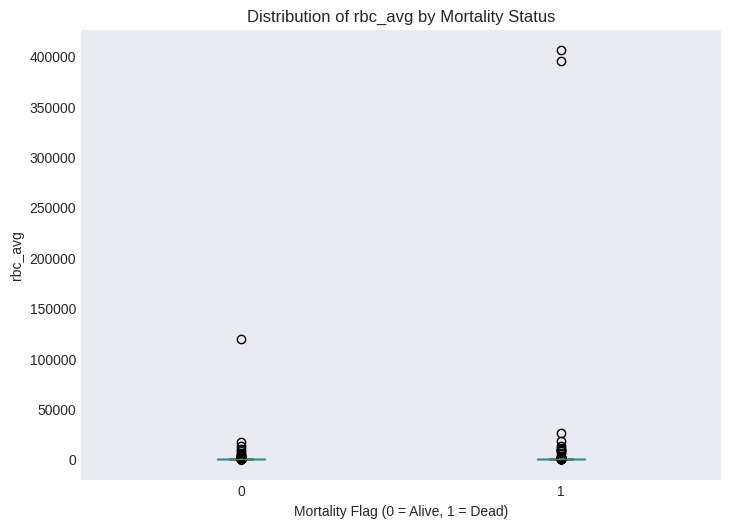

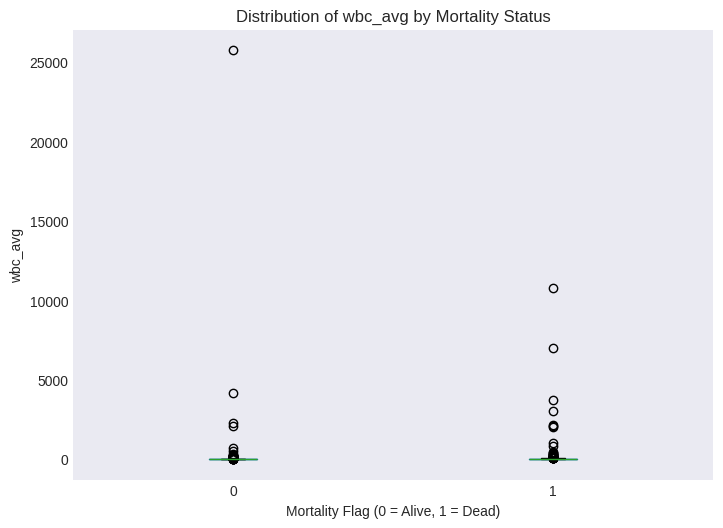

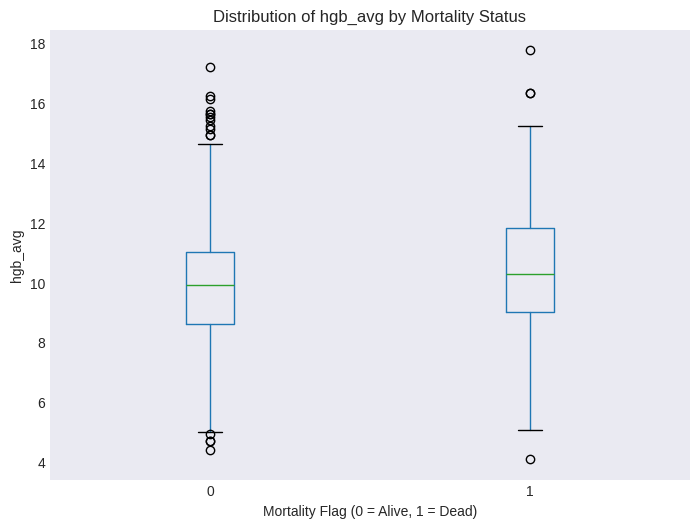

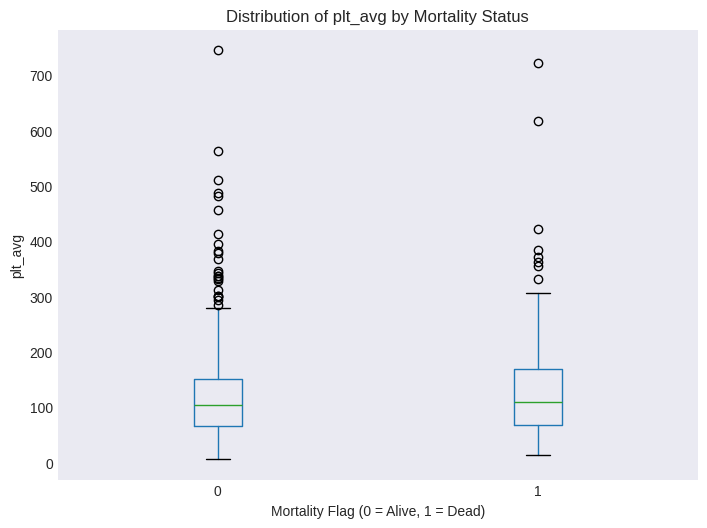

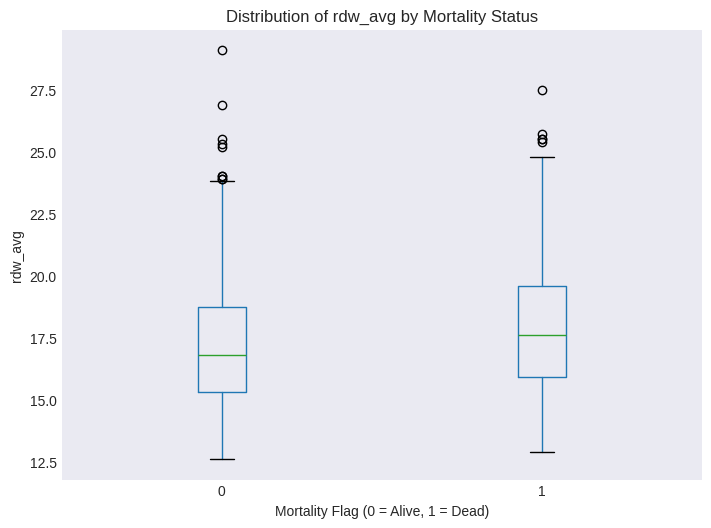

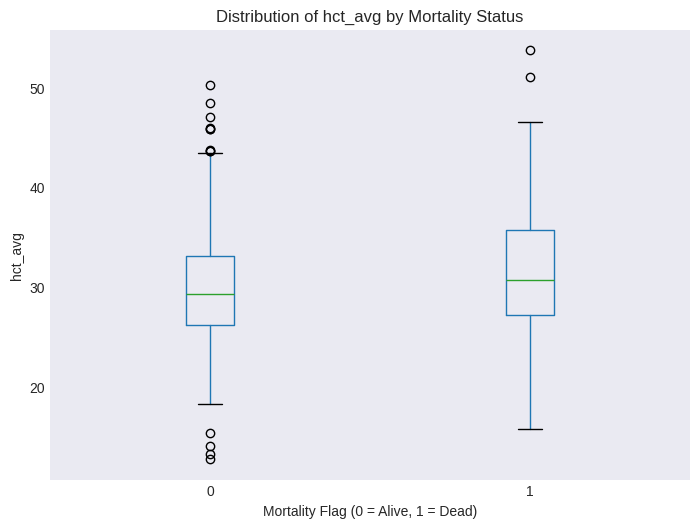

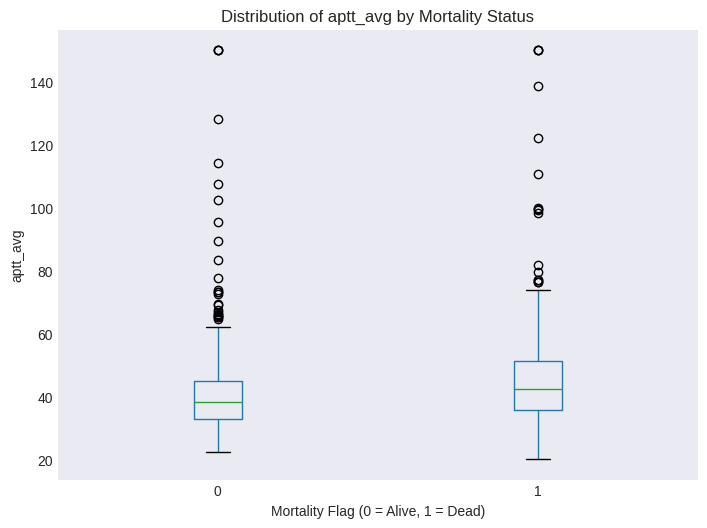

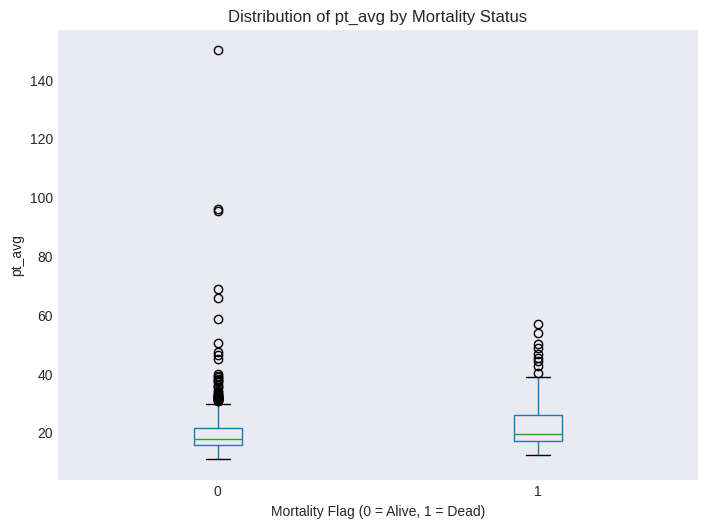

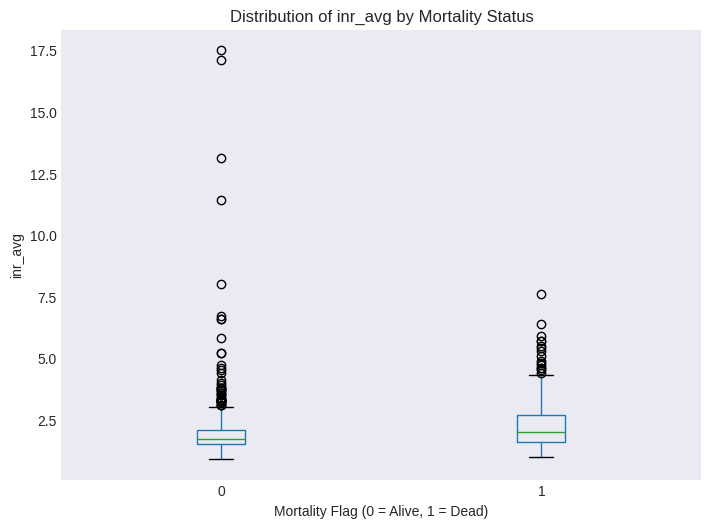

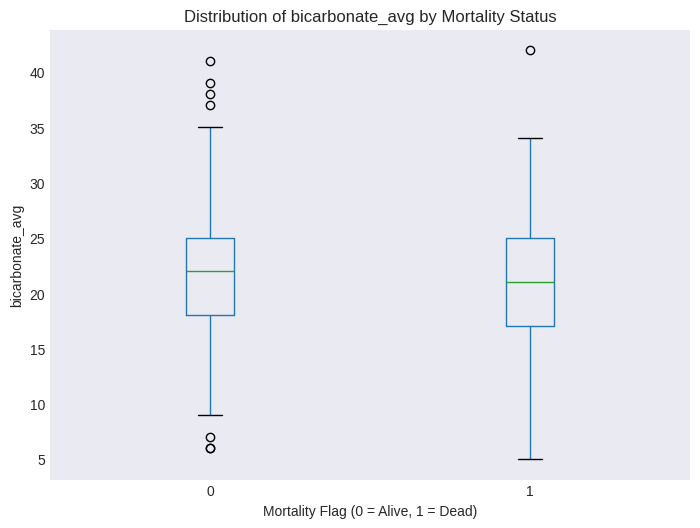

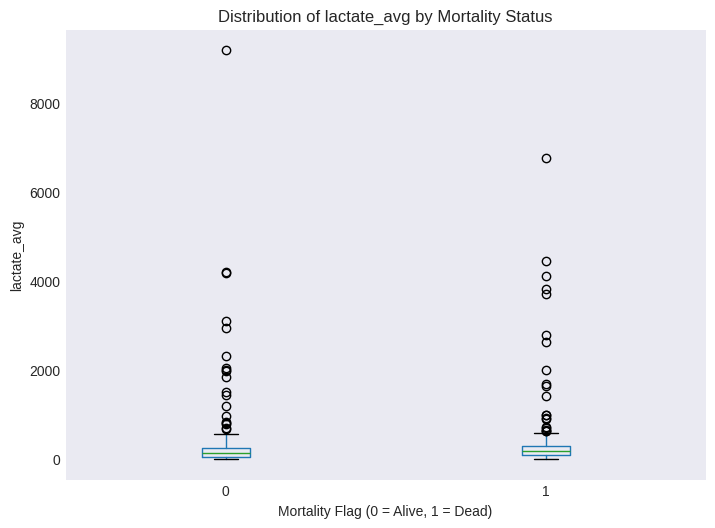

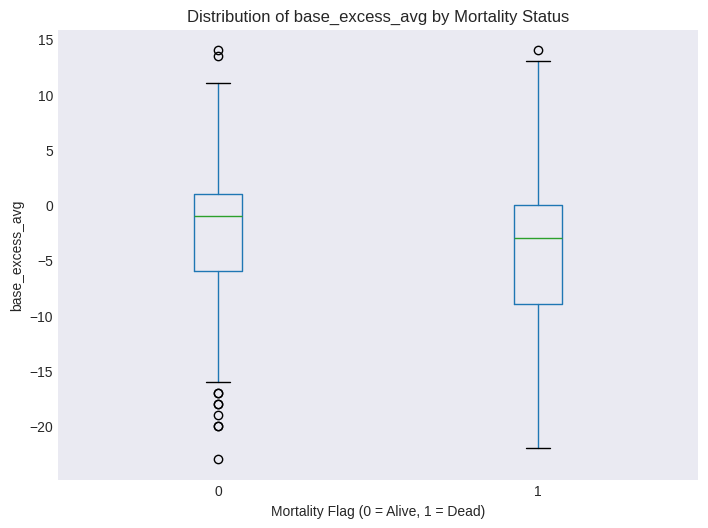

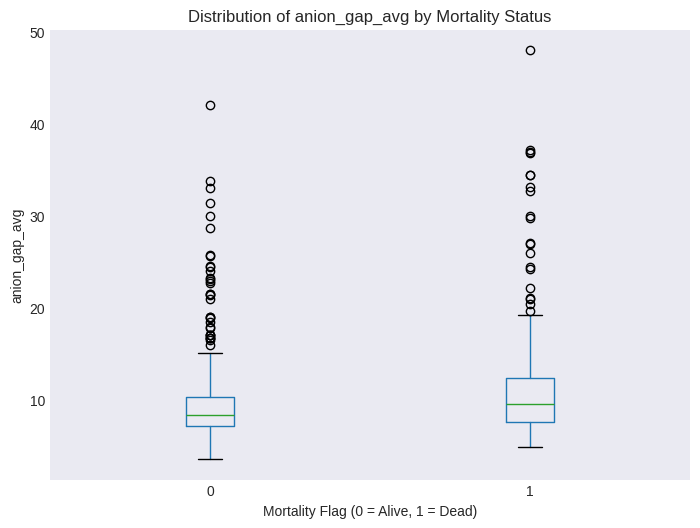

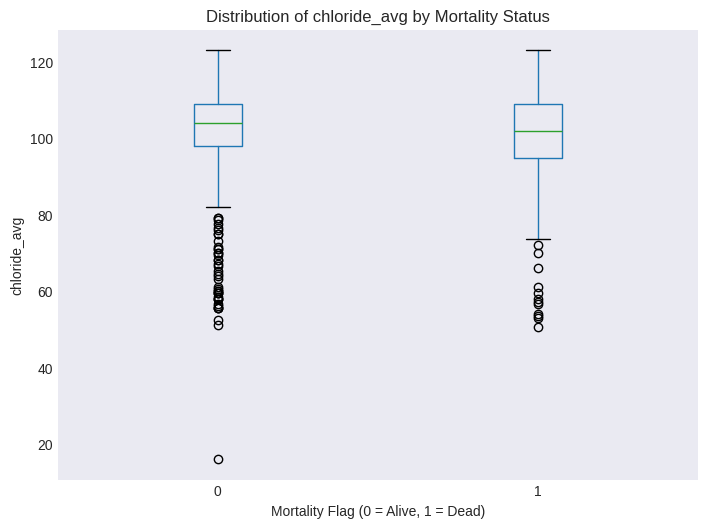

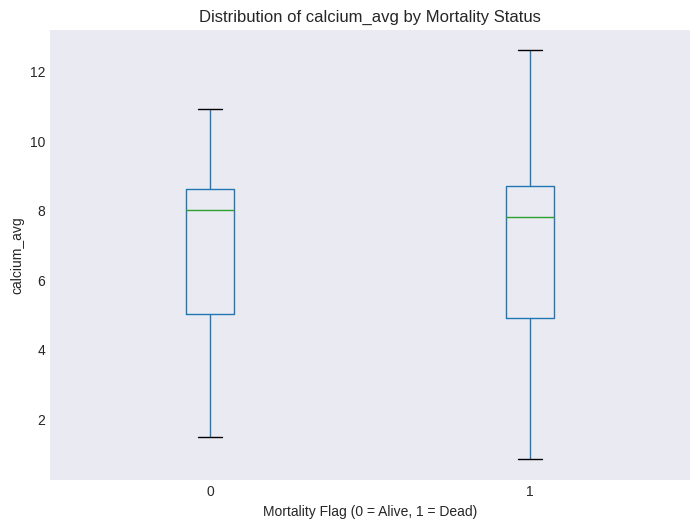

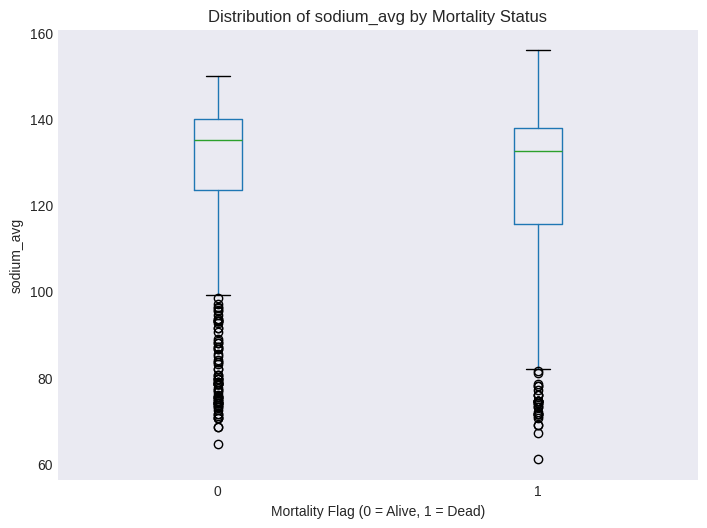

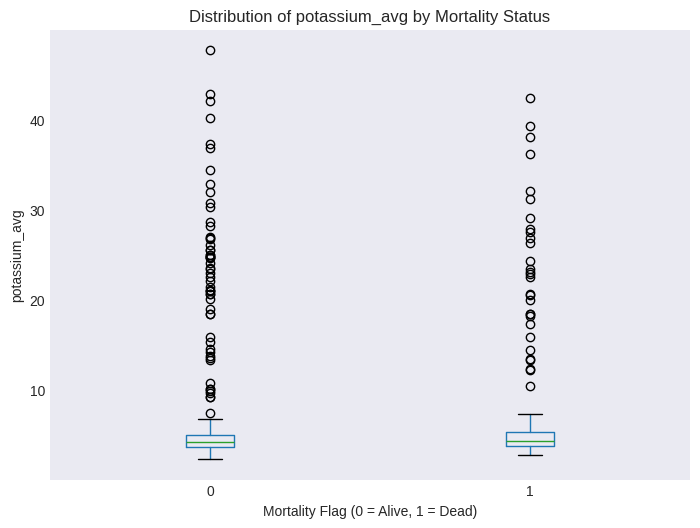

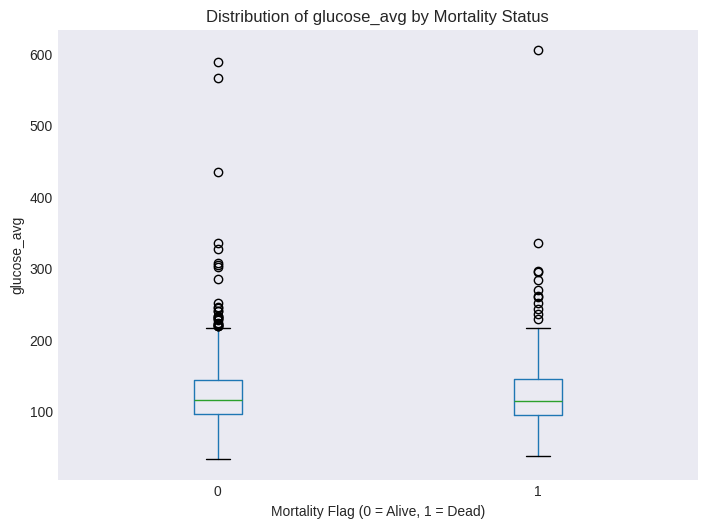

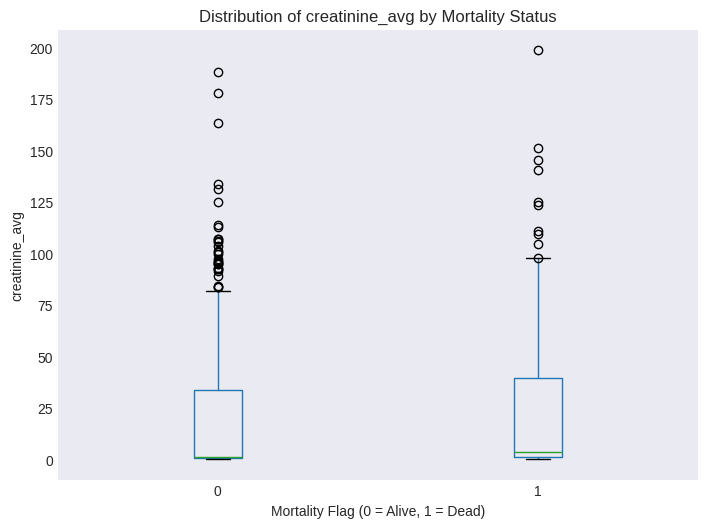

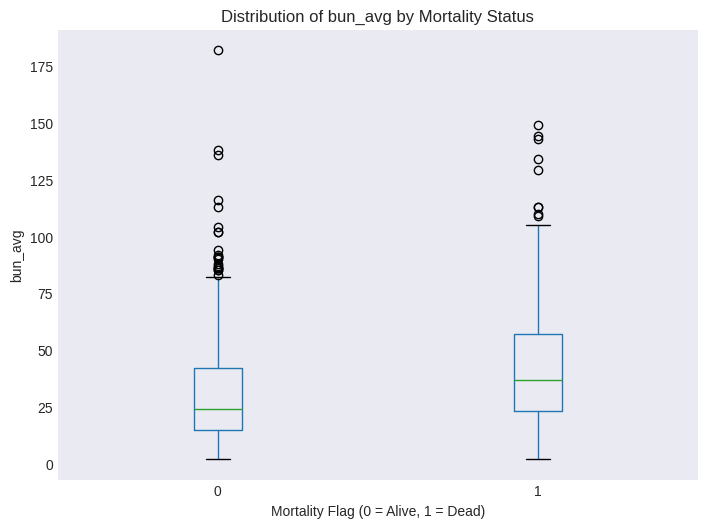

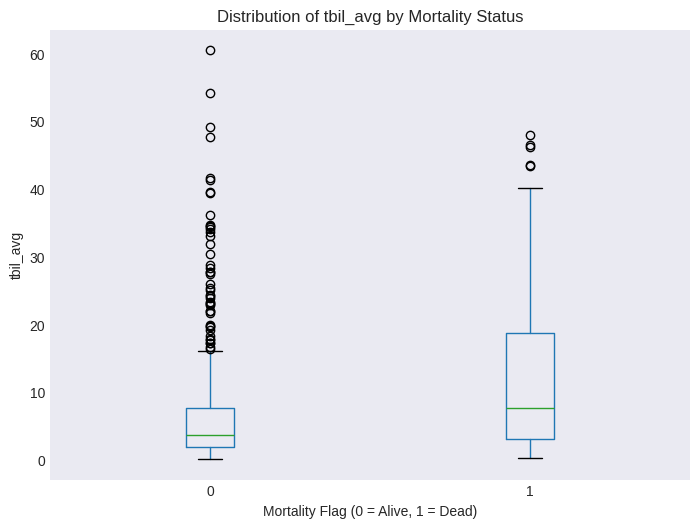

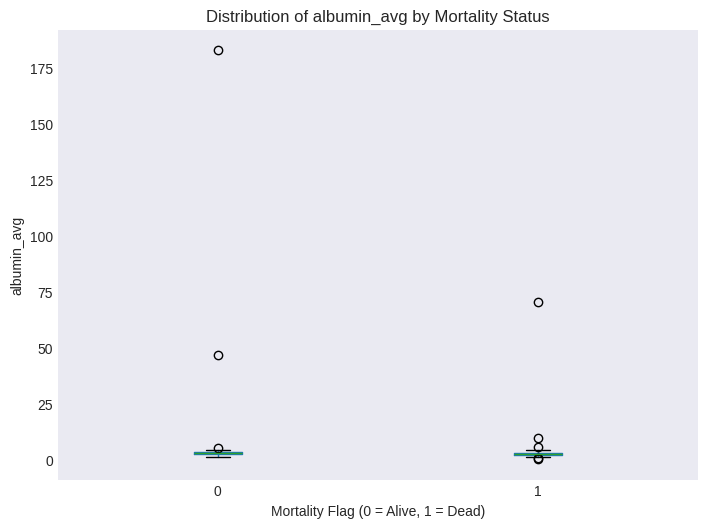

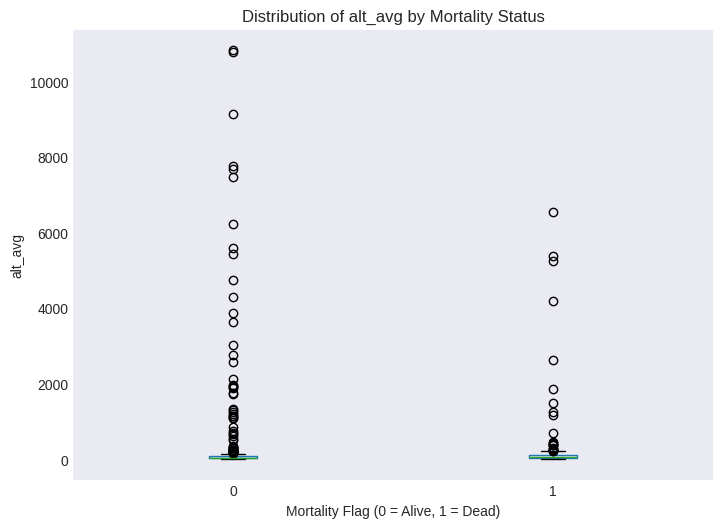

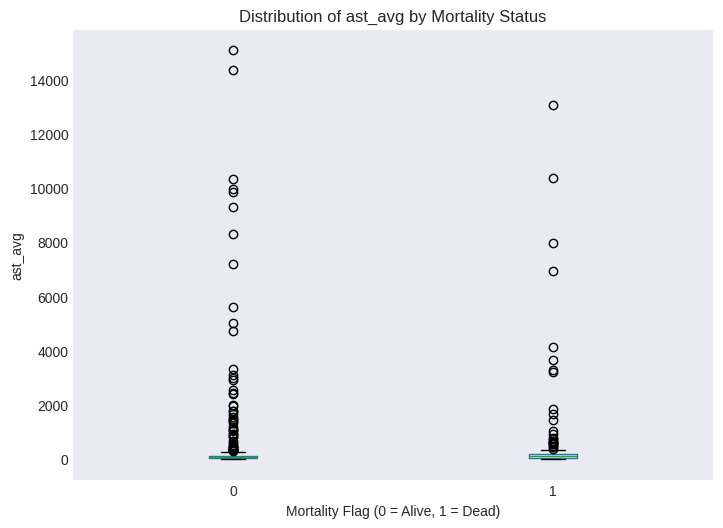

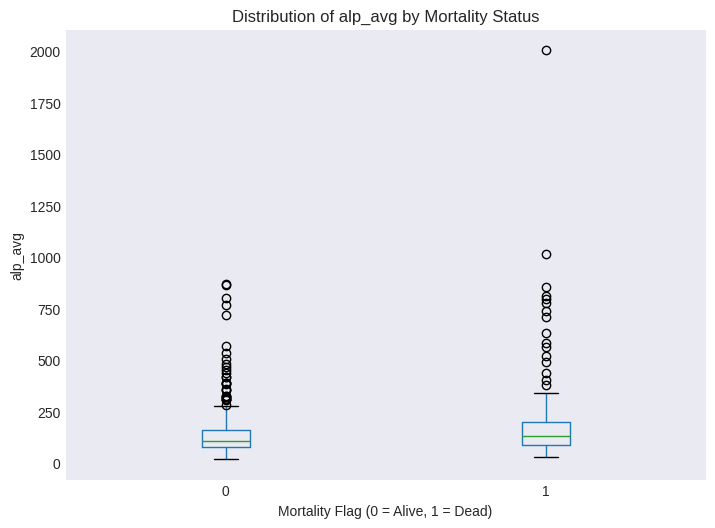

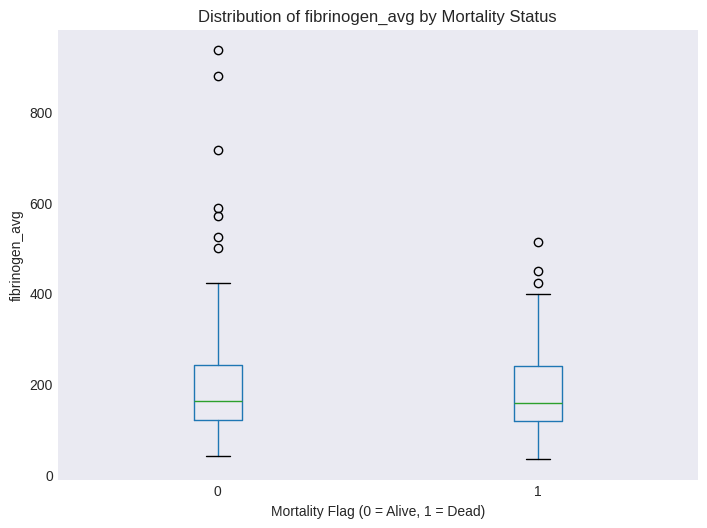

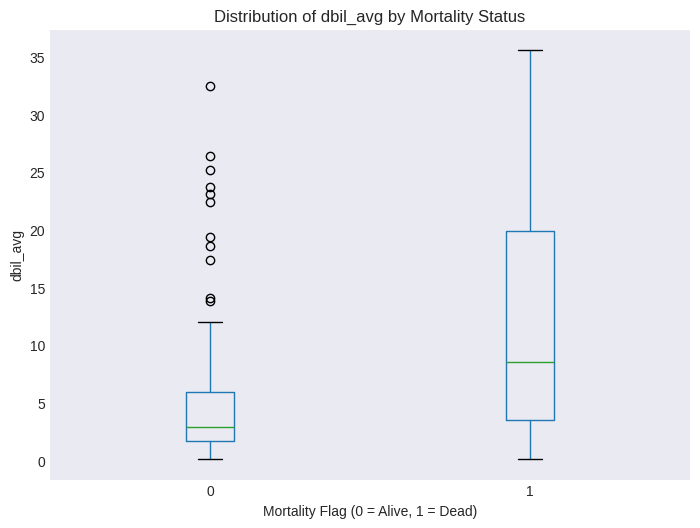

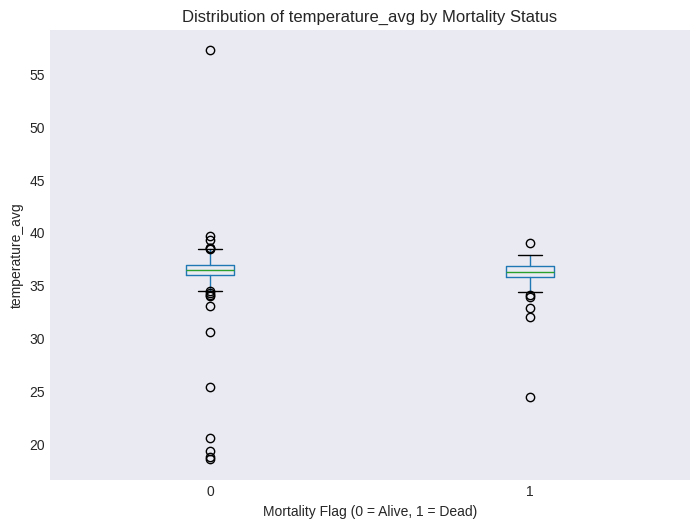

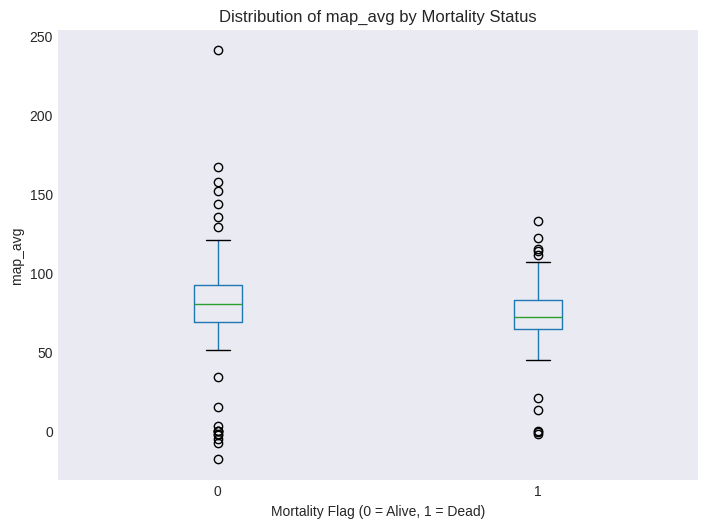

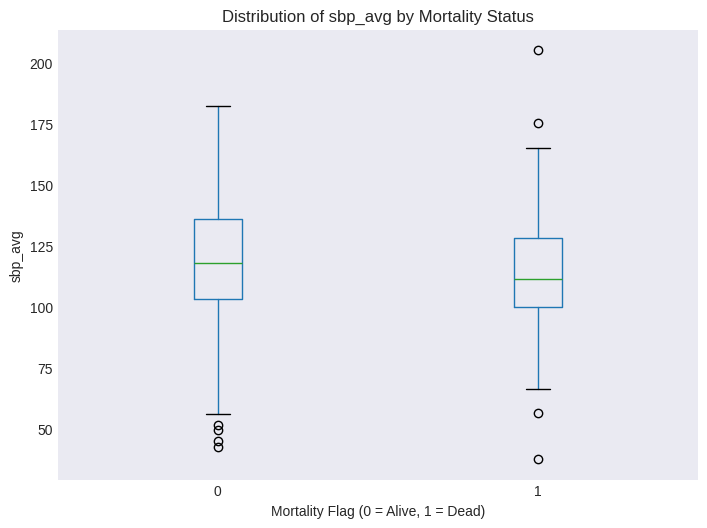

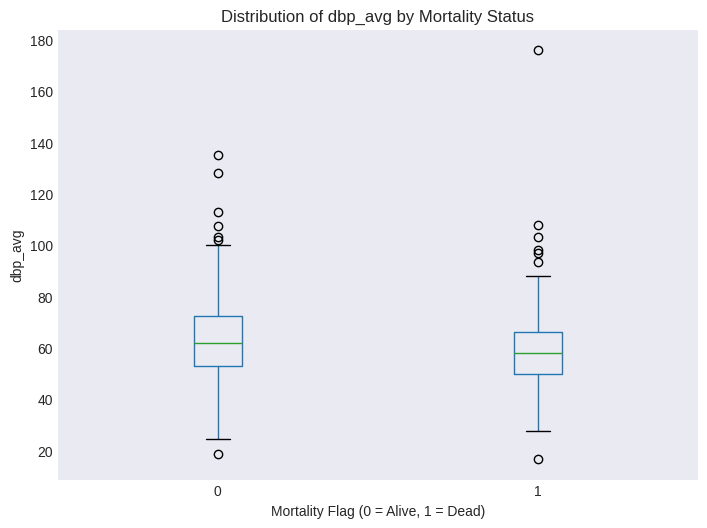

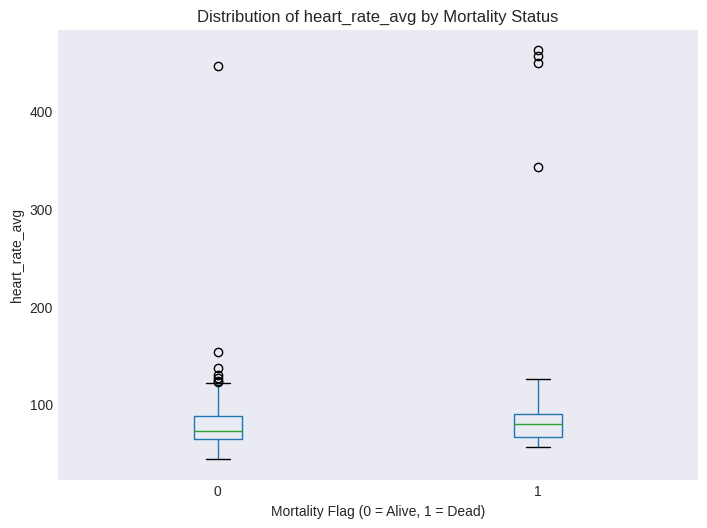

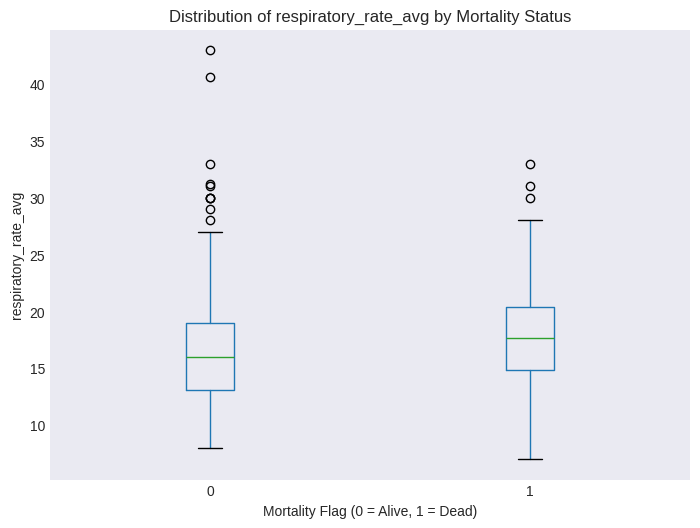

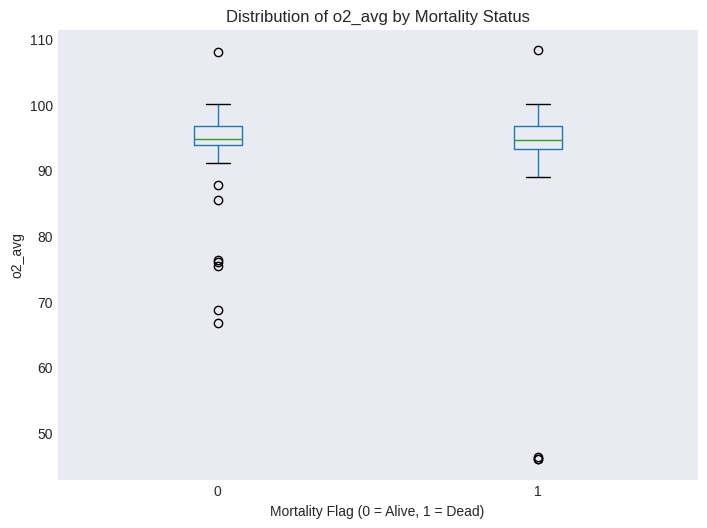

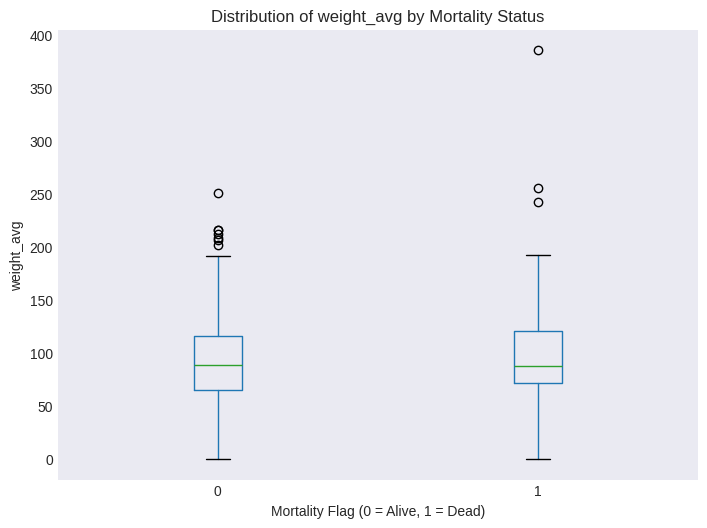

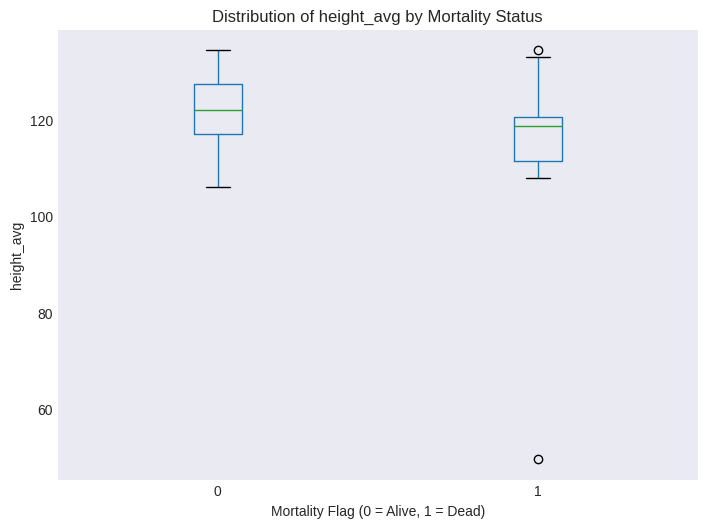

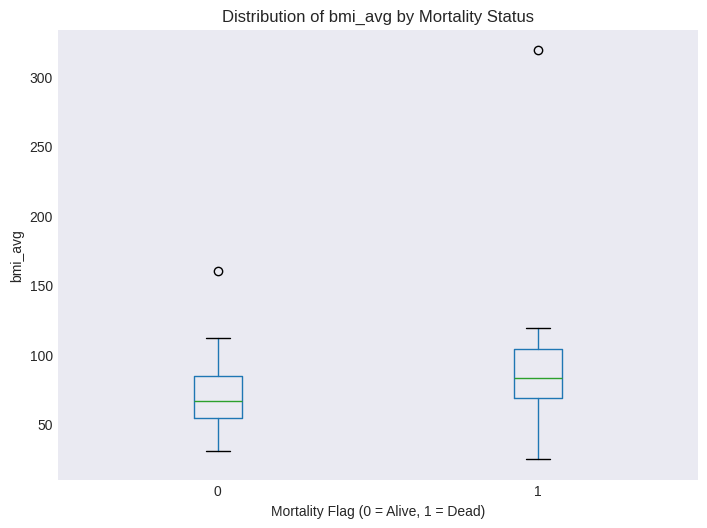

In [30]:
# Set up plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Create a box plot for each selected column, separated by mortality_flag
for column in columns_to_plot:
    plt.figure(figsize=(8, 6))
    df_avg.boxplot(column=column, by='mortality_flag', ax=plt.gca(), grid=False)
    plt.title(f'Distribution of {column} by Mortality Status')
    plt.suptitle('') # Suppress the automatic suptitle created by 'by'
    plt.xlabel('Mortality Flag (0 = Alive, 1 = Dead)')
    plt.ylabel(column)
    plt.show()

**Due to real world data, it has some totally impossible values due to human mistakes, Need to first remove those using boundaries**

## Removing Impossible Outliers

***research on temperature and map_avg***

In [31]:
import numpy as np
# Update plausible physiological ranges to include more variables
# Values outside these ranges will be considered 'real' outliers and set to NaN
# Extending the previous bounds with the newly requested variables
outlier_bounds_extended = {
    # Complete Blood Count (CBC)
    'rbc_avg': (1.0, 8.0),                 # ×10⁶/µL
    'wbc_avg': (0.1, 300.0),               # ×10³/µL
    'hgb_avg': (2.0, 25.0),                # g/dL
    'plt_avg': (5.0, 2000.0),              # ×10³/µL
    'rdw_avg': (8.0, 40.0),                # %
    'hct_avg': (10.0, 75.0),               # %

    # Coagulation
    'aptt_avg': (15.0, 180.0),             # sec
    'pt_avg': (8.0, 120.0),                # sec
    'inr_avg': (0.5, 15.0),                # ratio
    'fibrinogen_avg': (20.0, 1200.0),      # mg/dL

    # Blood Gas / Acid-Base
    'bicarbonate_avg': (2.0, 60.0),        # mmol/L
    'lactate_avg': (0.2, 30.0),            # mmol/L
    'base_excess_avg': (-40.0, 40.0),      # mmol/L
    'anion_gap_avg': (0.0, 50.0),          # mmol/L

    # Electrolytes
    'chloride_avg': (60.0, 140.0),         # mmol/L
    'calcium_avg': (4.0, 20.0),            # mg/dL
    'sodium_avg': (100.0, 190.0),          # mmol/L
    'potassium_avg': (1.5, 10.0),          # mmol/L

    # Renal / Metabolic
    'glucose_avg': (20.0, 1500.0),         # mg/dL
    'creatinine_avg': (0.1, 25.0),         # mg/dL
    'bun_avg': (2.0, 250.0),               # mg/dL

    # Liver Function
    'tbil_avg': (0.0, 60.0),               # mg/dL
    'dbil_avg': (0.0, 40.0),               # mg/dL
    'albumin_avg': (0.5, 7.0),             # g/dL
    'alt_avg': (1.0, 10000.0),             # U/L
    'ast_avg': (1.0, 10000.0),             # U/L
    'alp_avg': (10.0, 3000.0),             # U/L

    # Vitals
    'temperature_avg': (28, 45),  #(82.4, 113.0),      # °F (28°C–45°C)
    'map_avg': (20.0, 200.0),              # mmHg
    'sbp_avg': (40.0, 300.0),              # mmHg
    'dbp_avg': (10.0, 180.0),              # mmHg
    'heart_rate_avg': (20.0, 300.0),       # bpm
    'respiratory_rate_avg': (2.0, 80.0),   # breaths/min
    'o2_avg': (40.0, 100.0),               # SpO₂ (%)

    # Anthropometrics
    'weight_avg': (20.0, 350.0),           # kg
    'height_avg': (100.0, 250.0),          # cm
    'bmi_avg': (8.0, 100.0),               # kg/m²
}

# Apply the extended outlier removal
print("Cleaning 'real' outliers with extended bounds...")
for col, bounds in outlier_bounds_extended.items():
    if col in df_avg.columns:
        original_nan_count = df_avg[col].isnull().sum()
        # Set values below min to NaN
        df_avg.loc[df_avg[col] < bounds[0], col] = np.nan
        # Set values above max to NaN
        df_avg.loc[df_avg[col] > bounds[1], col] = np.nan
        new_nan_count = df_avg[col].isnull().sum()
        removed_count = new_nan_count - original_nan_count
        if removed_count > 0:
            print(f"  Removed {removed_count} outliers from '{col}' (values outside {bounds[0]}-{bounds[1]})")
    else:
        print(f"  Warning: Column '{col}' not found in df_avg.")

print("Extended outlier cleaning complete.")

Cleaning 'real' outliers with extended bounds...
  Removed 168 outliers from 'rbc_avg' (values outside 1.0-8.0)
  Removed 21 outliers from 'wbc_avg' (values outside 0.1-300.0)
  Removed 1 outliers from 'pt_avg' (values outside 8.0-120.0)
  Removed 2 outliers from 'inr_avg' (values outside 0.5-15.0)
  Removed 422 outliers from 'lactate_avg' (values outside 0.2-30.0)
  Removed 23 outliers from 'chloride_avg' (values outside 60.0-140.0)
  Removed 42 outliers from 'calcium_avg' (values outside 4.0-20.0)
  Removed 126 outliers from 'sodium_avg' (values outside 100.0-190.0)
  Removed 81 outliers from 'potassium_avg' (values outside 1.5-10.0)
  Removed 203 outliers from 'creatinine_avg' (values outside 0.1-25.0)
  Removed 1 outliers from 'tbil_avg' (values outside 0.0-60.0)
  Removed 5 outliers from 'albumin_avg' (values outside 0.5-7.0)
  Removed 2 outliers from 'alt_avg' (values outside 1.0-10000.0)
  Removed 6 outliers from 'ast_avg' (values outside 1.0-10000.0)
  Removed 7 outliers from '

## Again, Box Plots of Labs + Vitals

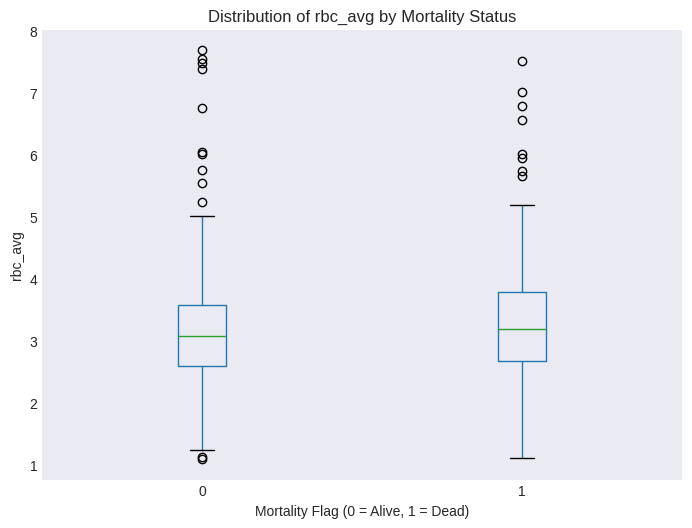

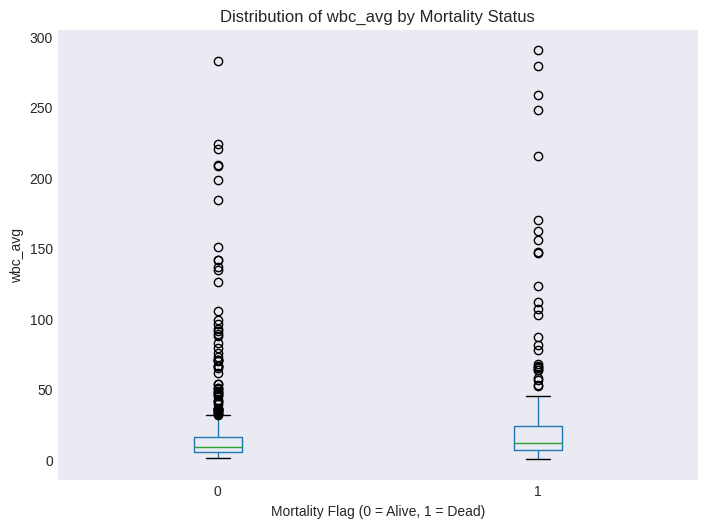

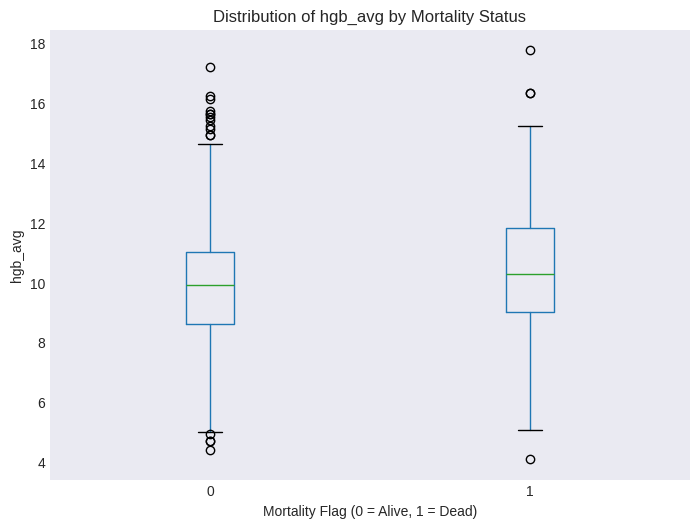

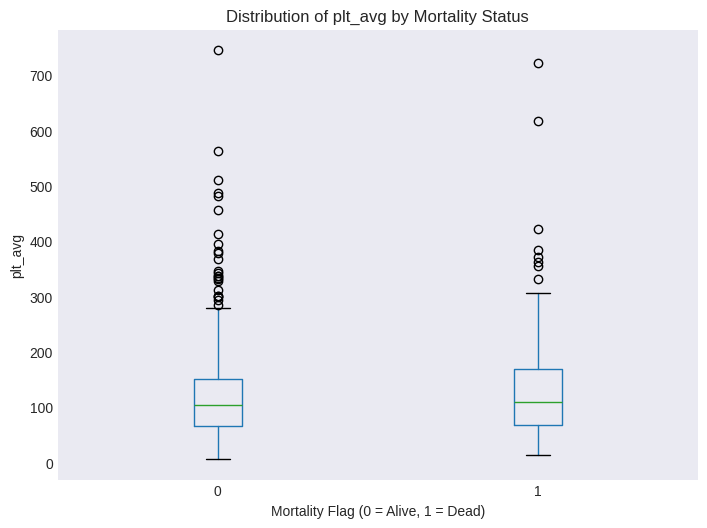

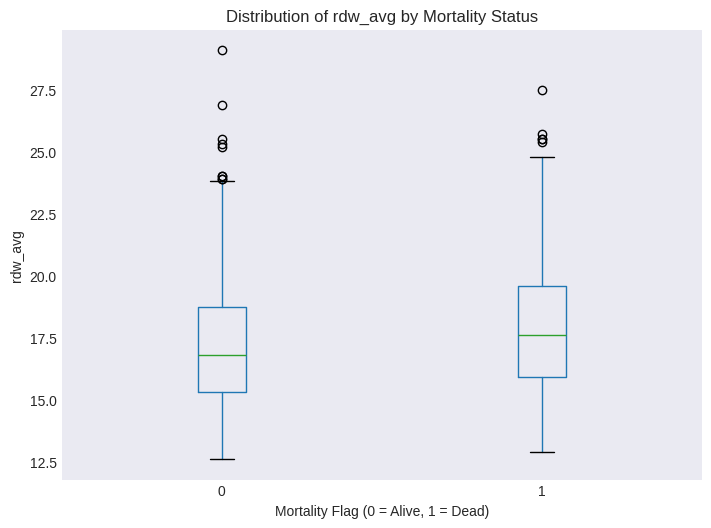

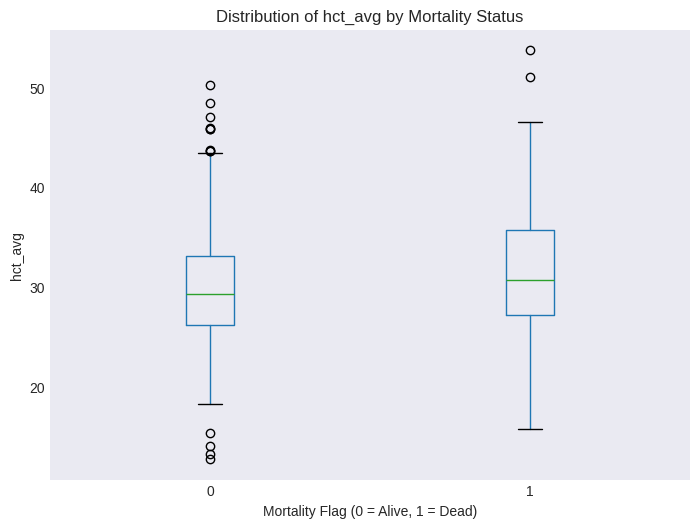

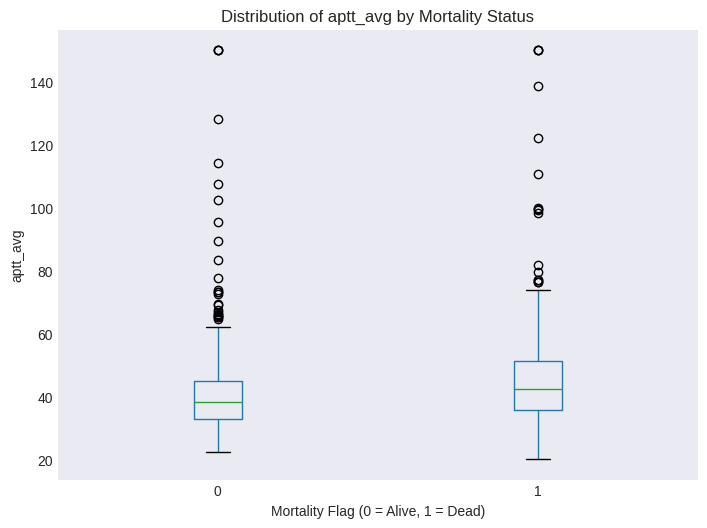

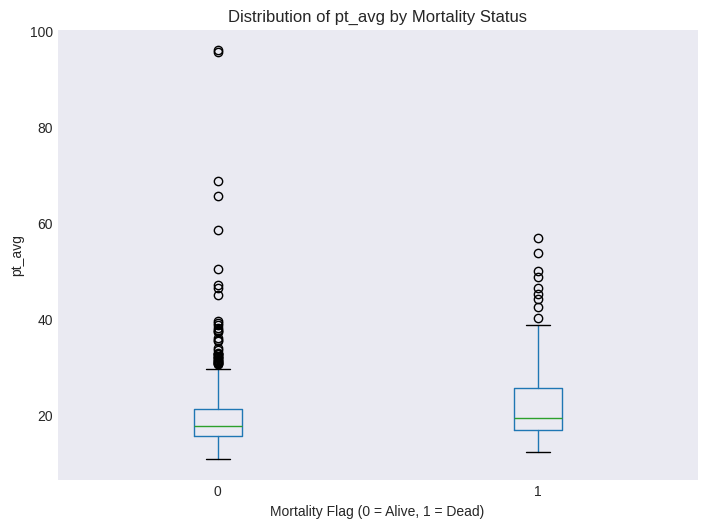

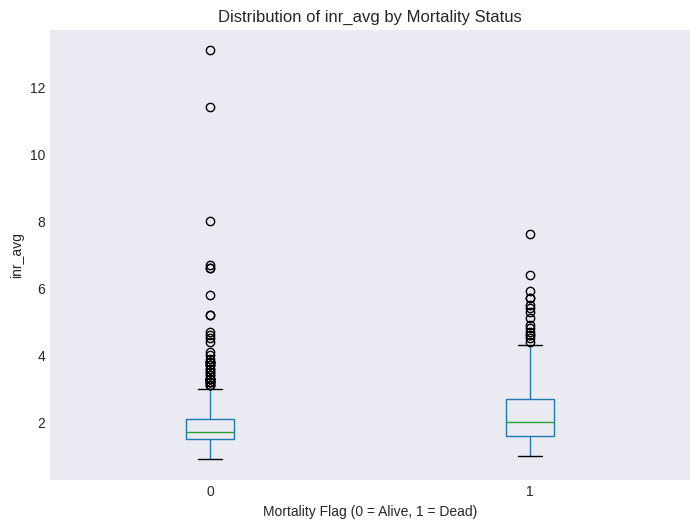

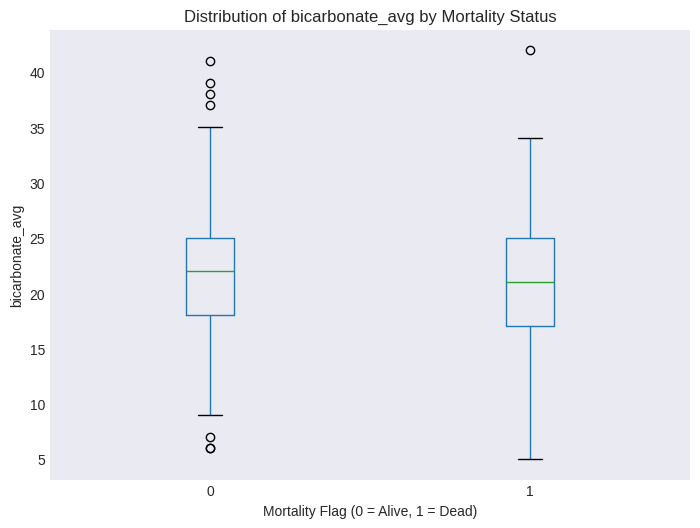

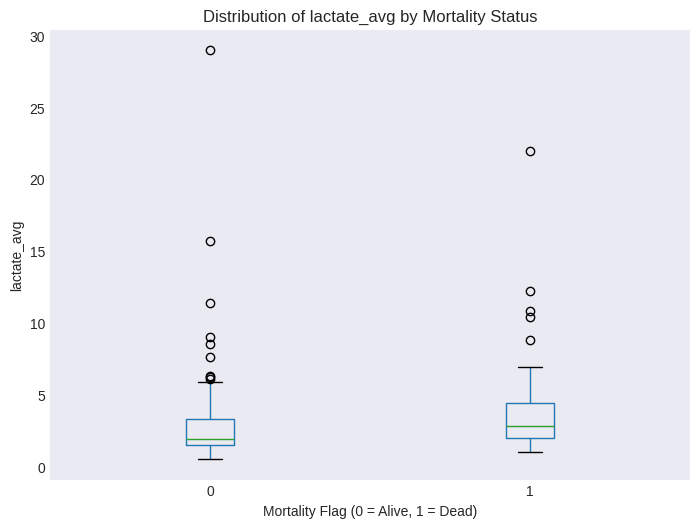

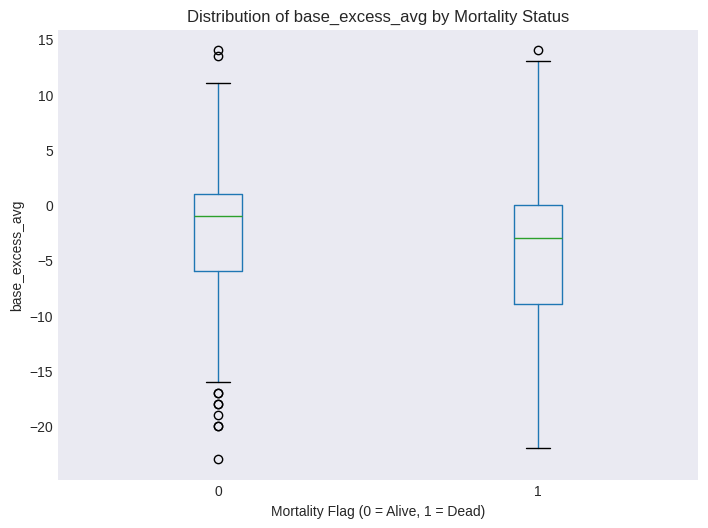

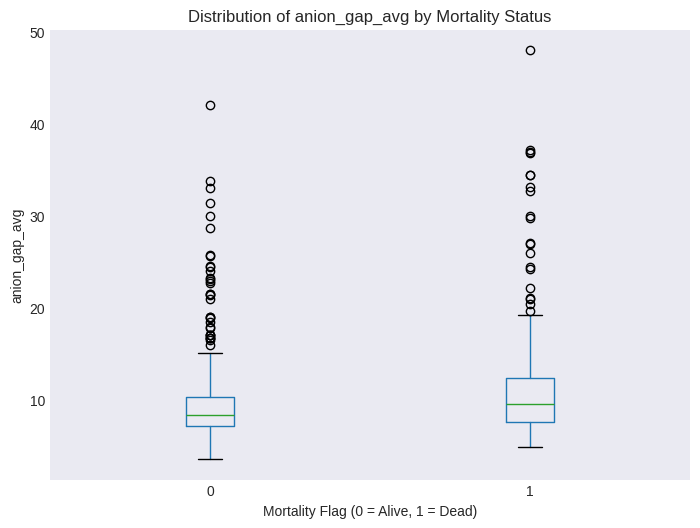

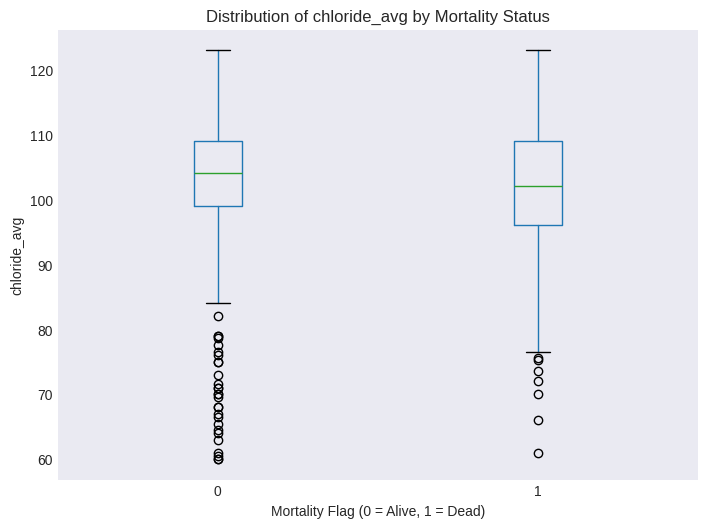

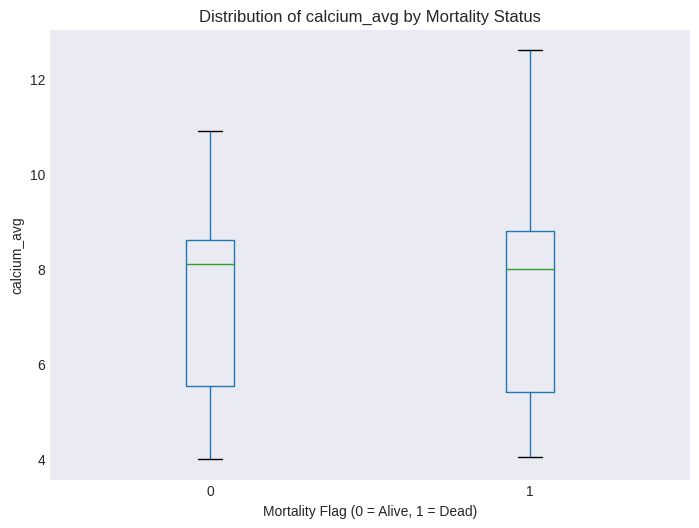

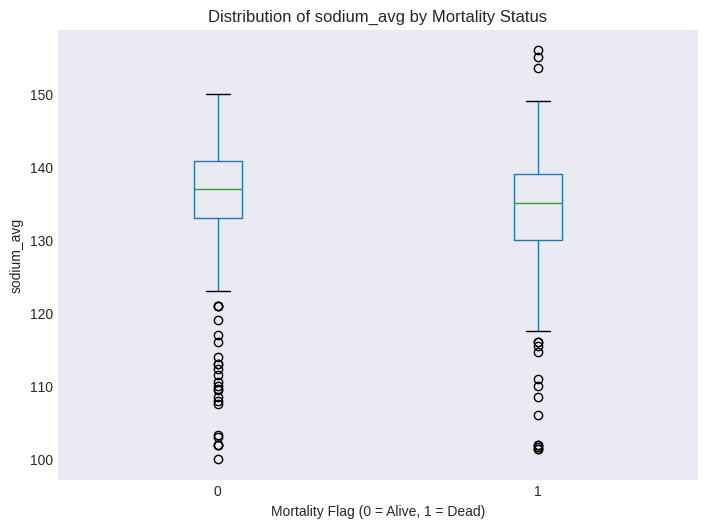

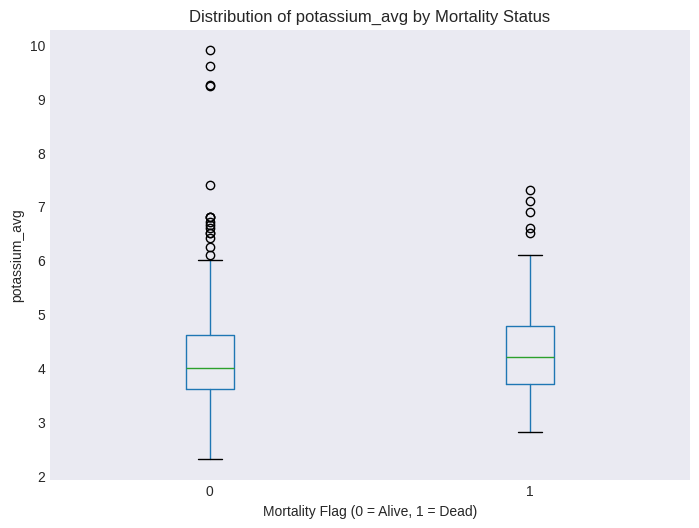

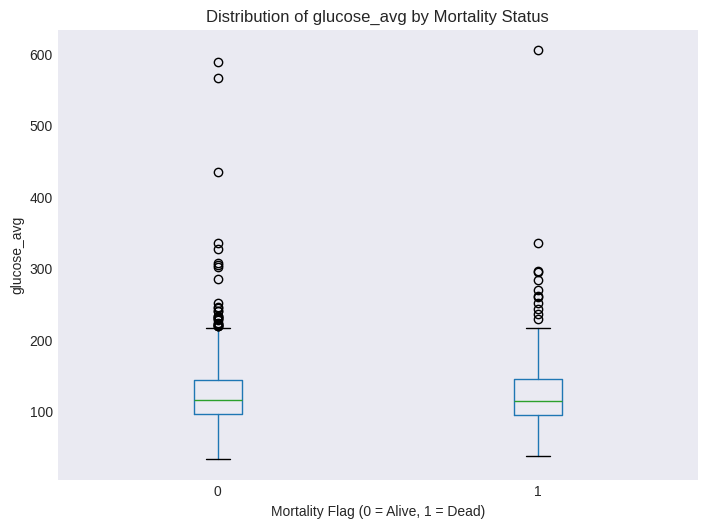

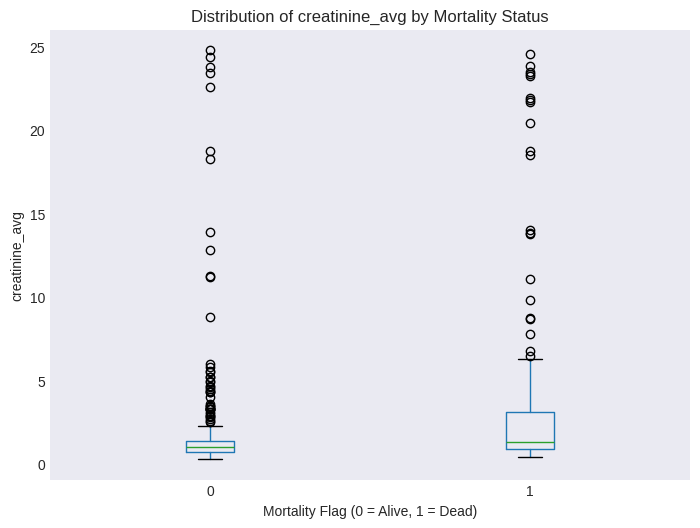

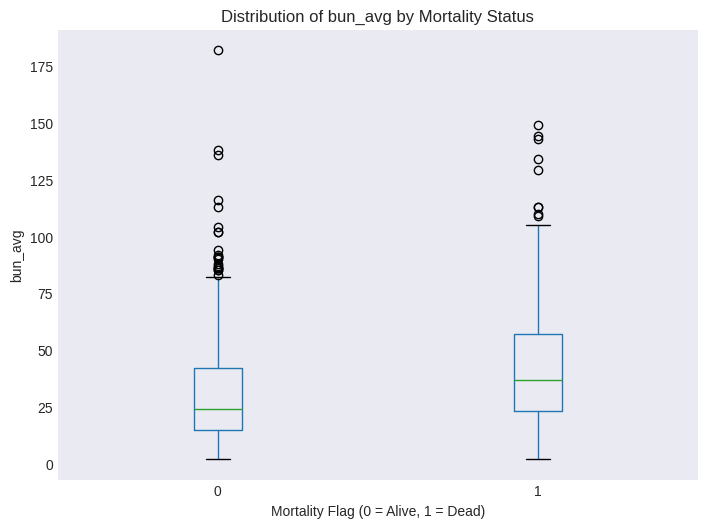

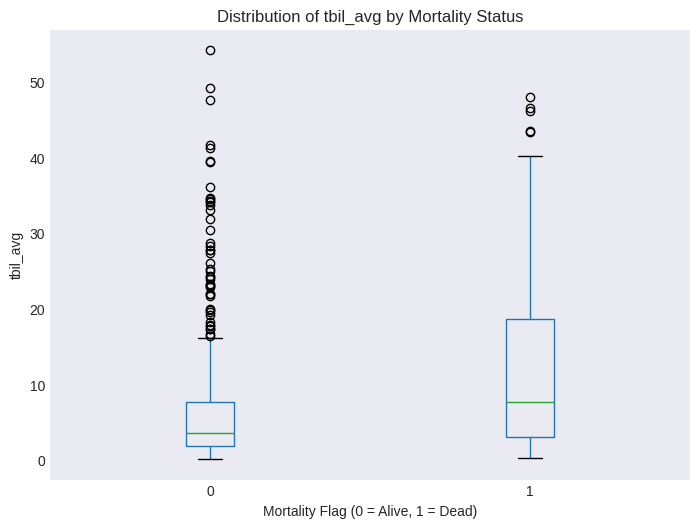

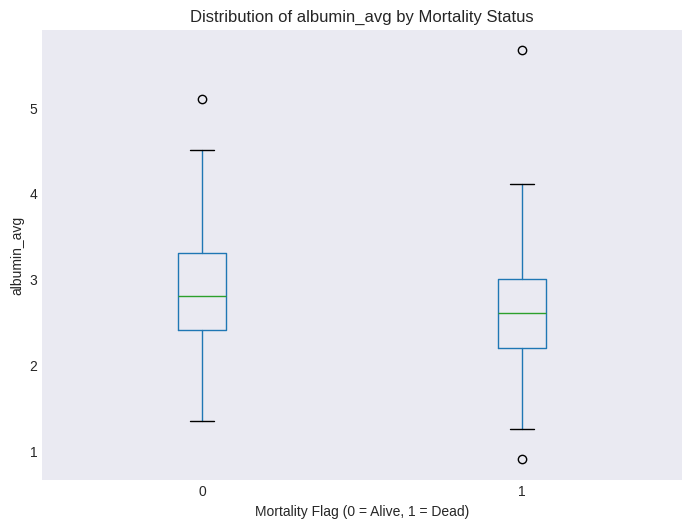

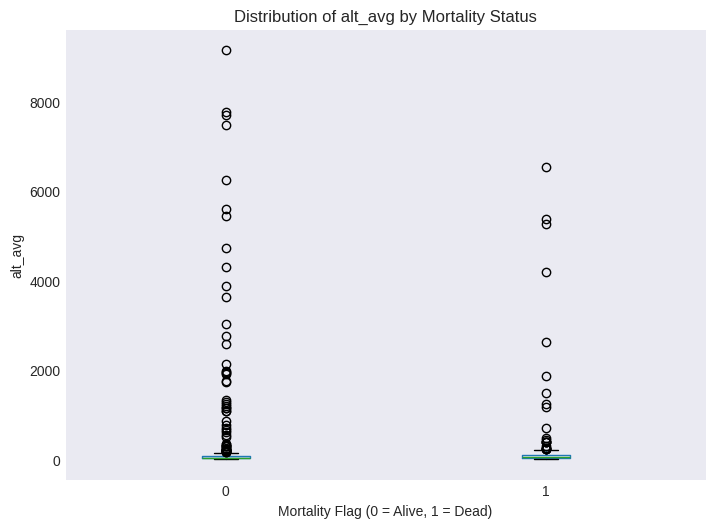

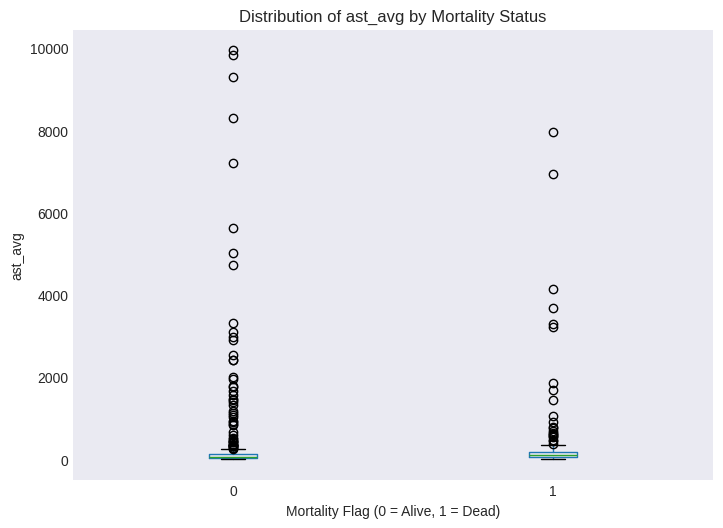

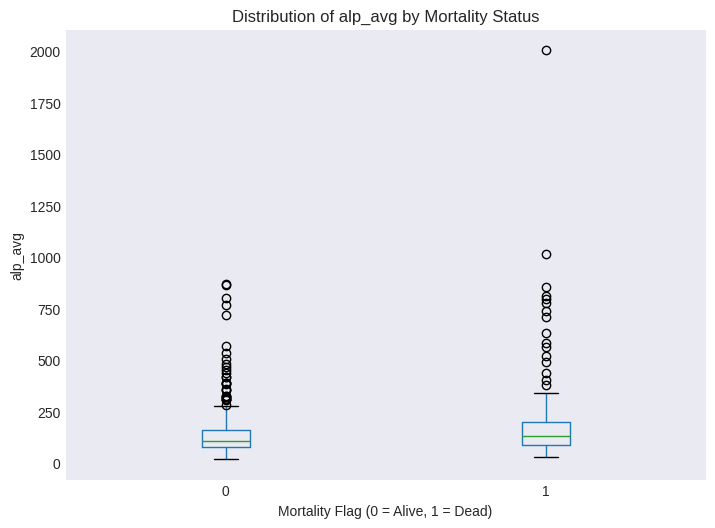

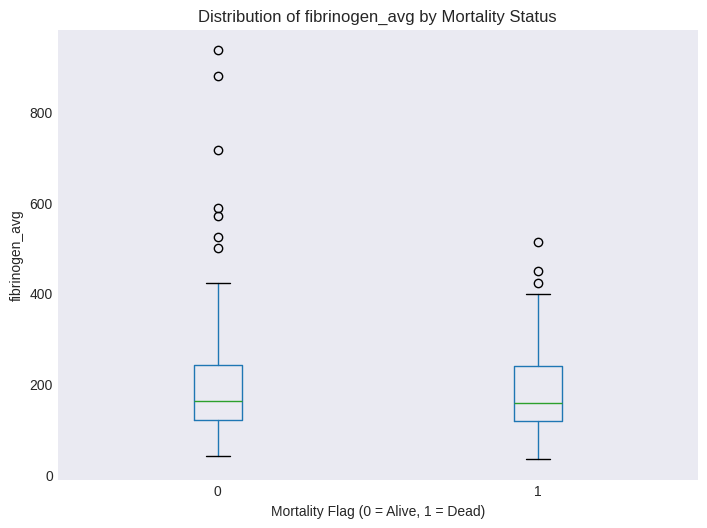

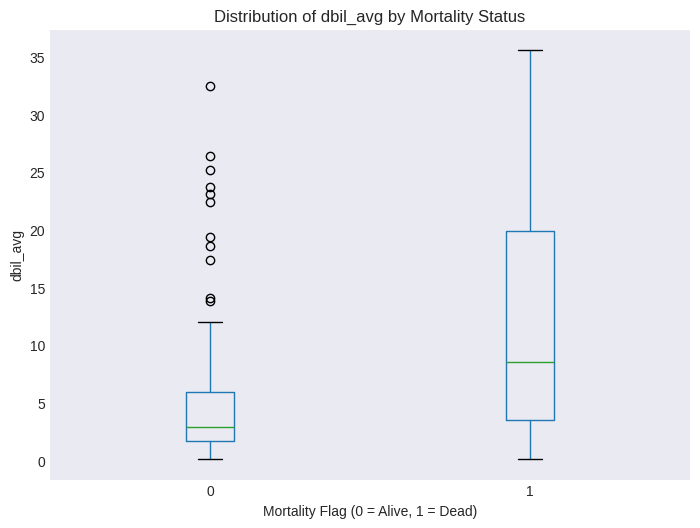

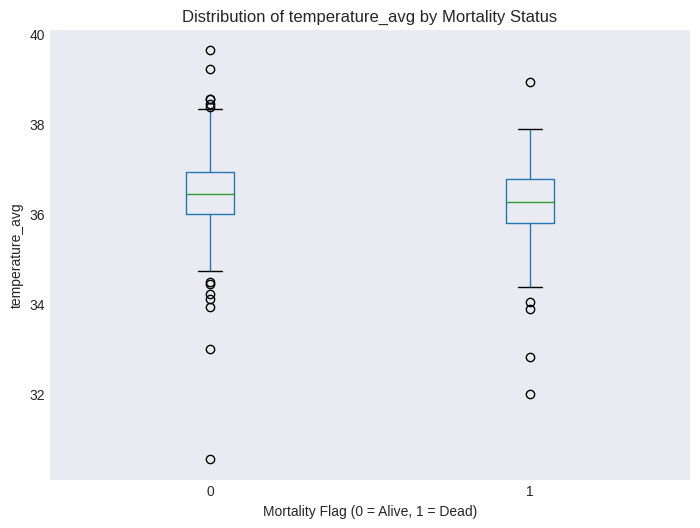

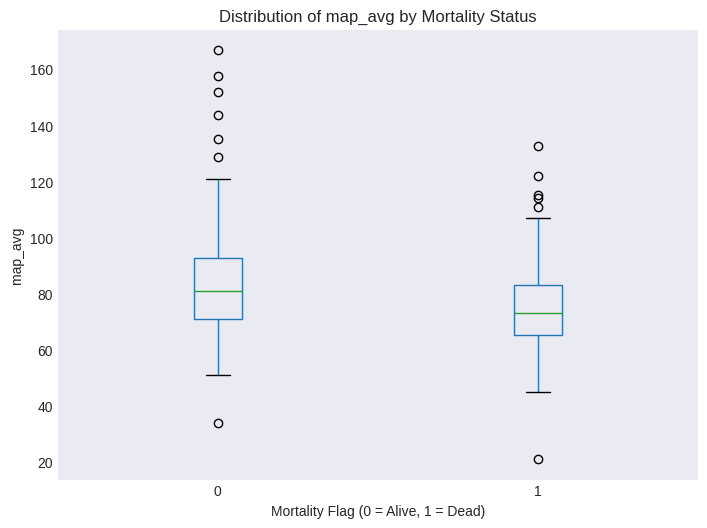

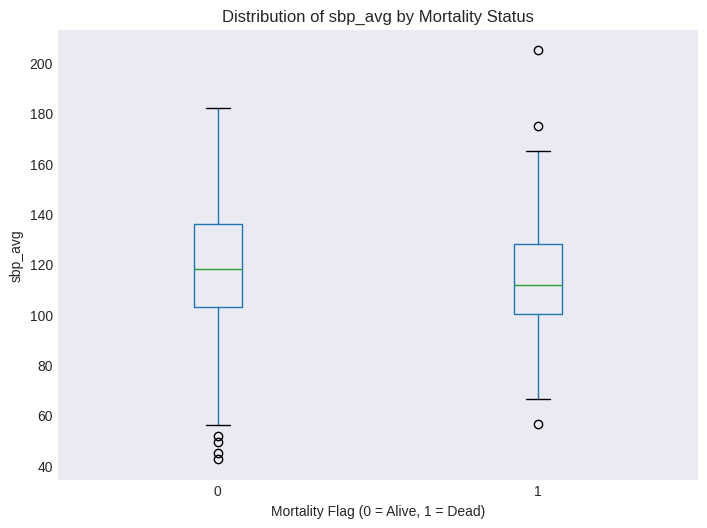

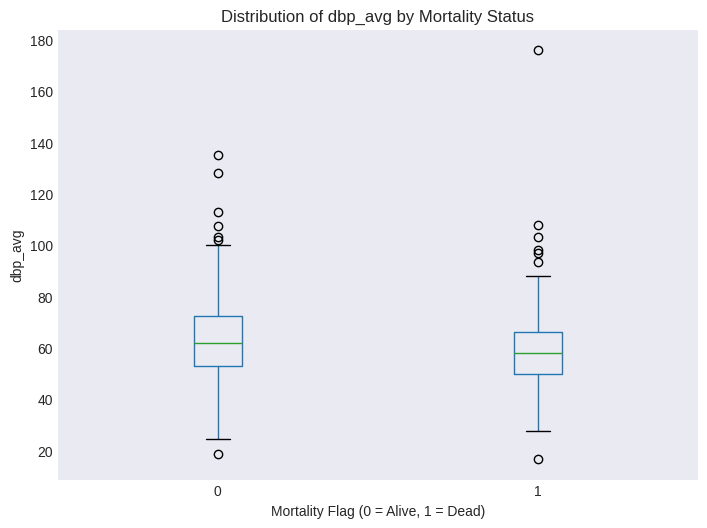

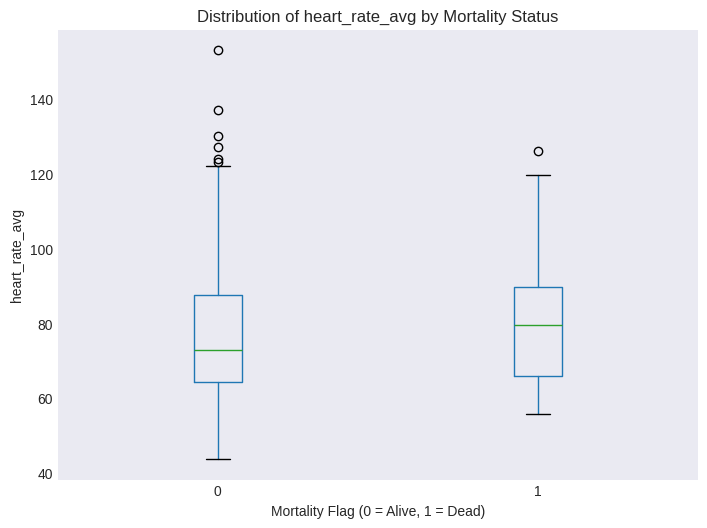

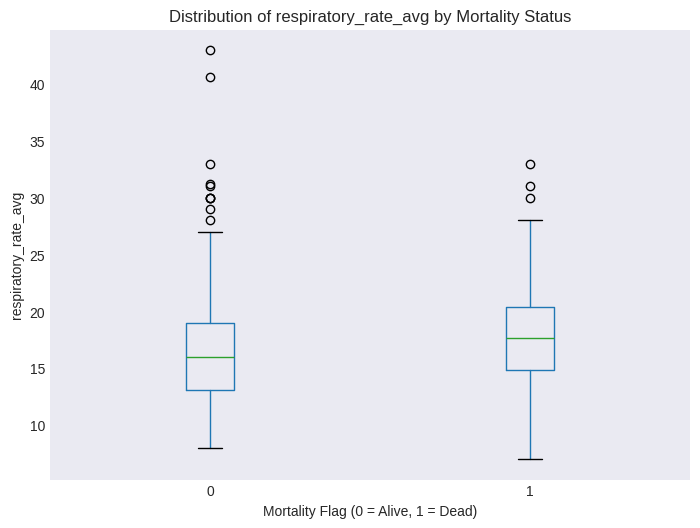

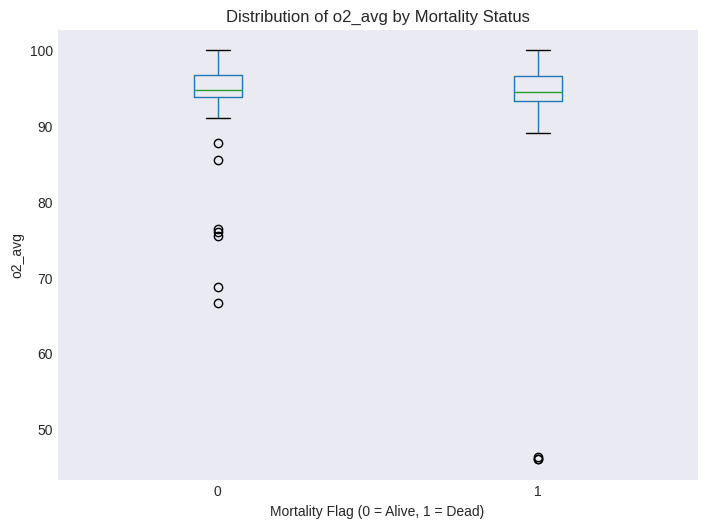

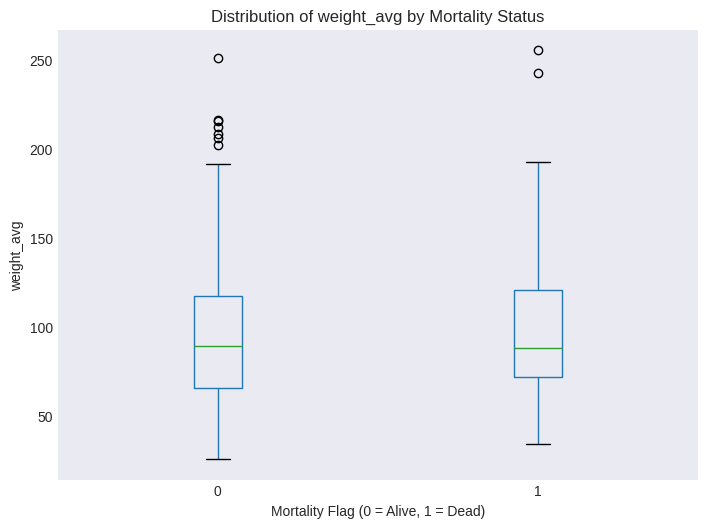

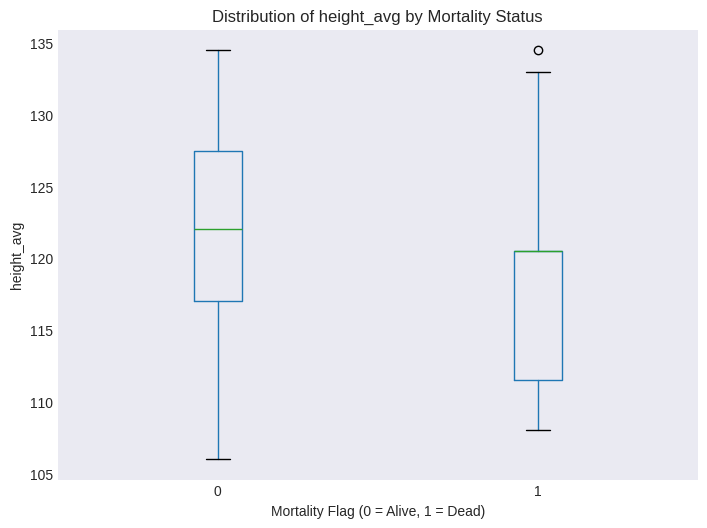

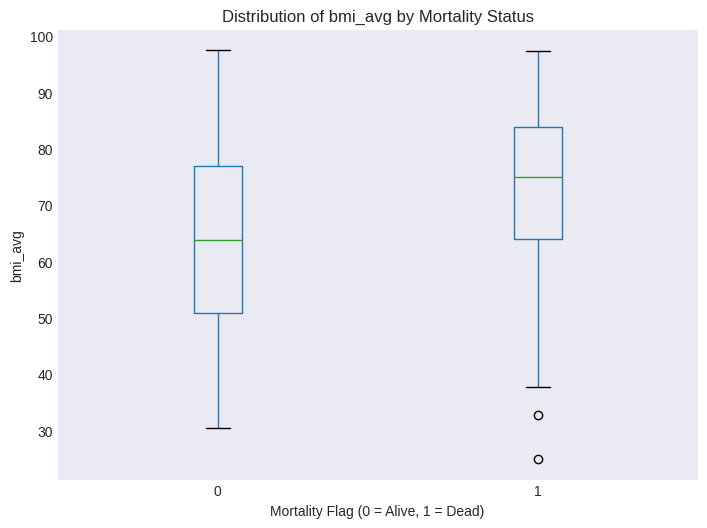

In [32]:
import matplotlib.pyplot as plt

# Identify columns to plot: all numeric columns in df_avg, excluding comorbidity_cols and 'mortality_flag'
# Make sure to only include columns that are actually in df_avg
columns_to_plot = [col for col in df_avg.select_dtypes(include=np.number).columns
                   if col not in comorbidity_cols and col != 'mortality_flag']

# Filter out columns that are entirely NaN, as box plots won't be useful for them
columns_to_plot = [col for col in columns_to_plot if not df_avg[col].isnull().all()]

# Set up plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Create a box plot for each selected column, separated by mortality_flag
for column in columns_to_plot:
    plt.figure(figsize=(8, 6))
    df_avg.boxplot(column=column, by='mortality_flag', ax=plt.gca(), grid=False)
    plt.title(f'Distribution of {column} by Mortality Status')
    plt.suptitle('') # Suppress the automatic suptitle created by 'by'
    plt.xlabel('Mortality Flag (0 = Alive, 1 = Dead)')
    plt.ylabel(column)
    plt.show()

# **Sex, Age, Race, Insurance**

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import pandas as pd

# Create a new DataFrame with only the relevant demographic columns and mortality_flag
df_demographics = df[['sex', 'age', 'race', 'insurance', 'mortality_flag']].copy()


In [34]:
df_demographics.isnull().sum()

,0
sex,0
age,0
race,0
insurance,0
mortality_flag,0


# Age


--- EDA for Age ---


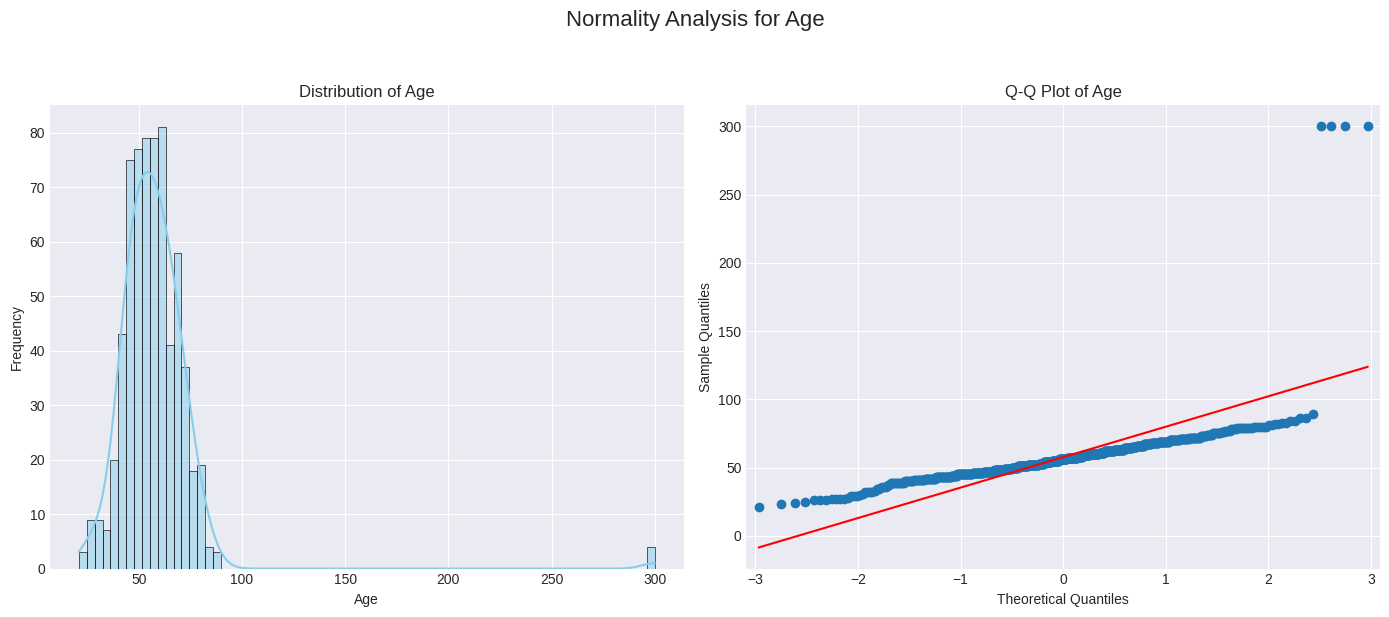

In [35]:
# --- 1. EDA for Age (Normality: Histogram and Q-Q plot) ---
print("\n--- EDA for Age ---")
age_data = df_demographics['age'].dropna() # Drop NaN values for age for plotting

if not age_data.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Histogram
    sns.histplot(age_data, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title('Distribution of Age')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Frequency')

    # Q-Q Normal Plot
    sm.qqplot(age_data, line='s', ax=axes[1])
    axes[1].set_title('Q-Q Plot of Age')
    axes[1].set_xlabel('Theoretical Quantiles')
    axes[1].set_ylabel('Sample Quantiles')

    plt.suptitle('Normality Analysis for Age', fontsize=16, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
else:
    print("Age column is empty or contains only NaN values after dropping NaNs.")




***very interesting result with age, so, most patients of hepatic encephalopathy are between age of 40-75. And age is normally distributed***

In [36]:
from scipy.stats import mannwhitneyu

print("\n--- P-test (Mann-Whitney U Test) for Age vs. Mortality ---")

# Separate age data into alive and dead groups
age_alive = df_demographics[df_demographics['mortality_flag'] == 0]['age'].dropna()
age_dead = df_demographics[df_demographics['mortality_flag'] == 1]['age'].dropna()

if not age_alive.empty and not age_dead.empty:
    # Perform the Mann-Whitney U test
    u_statistic, p_value = mannwhitneyu(age_alive, age_dead, alternative='two-sided')

    print(f"Mann-Whitney U Statistic: {u_statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value < 0.05:
        print("Conclusion: There is a statistically significant difference in age distribution between alive and dead patients (p < 0.05).")
    else:
        print("Conclusion: There is no statistically significant difference in age distribution between alive and dead patients (p >= 0.05).")
else:
    print("Skipping test: Insufficient age data in one or both mortality groups after dropping NaNs.")



--- P-test (Mann-Whitney U Test) for Age vs. Mortality ---
Mann-Whitney U Statistic: 43140.0000
P-value: 0.0086
Conclusion: There is a statistically significant difference in age distribution between alive and dead patients (p < 0.05).


# Gender

In [37]:
# --- 2. Contingency Tables for Sex and Insurance vs. Mortality Flag ---
print("\n--- Contingency Tables ---")

# For Sex
print("\nContingency Table for Sex vs. Mortality Flag:")
contingency_sex = pd.crosstab(df_demographics['sex'], df_demographics['mortality_flag'])
contingency_sex.columns = ['Alive', 'Dead']
display(contingency_sex)



--- Contingency Tables ---

Contingency Table for Sex vs. Mortality Flag:


,Alive,Dead
sex,,
F,165,80
M,279,142


***Nothing very important i guess can be deducted from the contingency table of gender/mortality***

In [38]:
from scipy.stats import chi2_contingency
import pandas as pd

print("\n--- Chi-square Test for Sex vs. Mortality ---")

# Create the contingency table for sex and mortality_flag
contingency_sex_mortality = pd.crosstab(df_demographics['sex'], df_demographics['mortality_flag'])
contingency_sex_mortality.columns = ['Alive', 'Dead']

print("Contingency Table for Sex vs. Mortality Flag:")
display(contingency_sex_mortality)

# Perform the Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_sex_mortality)

print(f"Chi-square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

if p_value < 0.05:
    print("Conclusion: There is a statistically significant association between sex and mortality (p < 0.05).")
else:
    print("Conclusion: There is no statistically significant association between sex and mortality (p >= 0.05).")



--- Chi-square Test for Sex vs. Mortality ---
Contingency Table for Sex vs. Mortality Flag:


,Alive,Dead
sex,,
F,165,80
M,279,142


Chi-square Statistic: 0.0395
P-value: 0.8424
Degrees of Freedom: 1
Conclusion: There is no statistically significant association between sex and mortality (p >= 0.05).


# Insurance

In [39]:
# For Insurance
print("\nContingency Table for Insurance vs. Mortality Flag:")
contingency_insurance = pd.crosstab(df_demographics['insurance'], df_demographics['mortality_flag'])
contingency_insurance.columns = ['Alive', 'Dead']
display(contingency_insurance)




Contingency Table for Insurance vs. Mortality Flag:


,Alive,Dead
insurance,,
Government,14,6
Medicaid,81,29
Medicare,151,87
Private,193,95
Self Pay,5,5


In [40]:
# Create a binary 'has_insurance' column
# Group 'Medicaid', 'Medicare', 'Private' as 'Insured', and 'Other' as 'No Insurance'
# Assuming 'Other' might represent a lack of standard insurance or a less defined category
df_demographics['has_insurance'] = df_demographics['insurance'].apply(lambda x: 'Insured' if x in ['Medicaid', 'Medicare', 'Private'] else 'No Insurance')

print("\n--- 2x2 Contingency Table for Insurance Status vs. Mortality Flag ---")
contingency_insurance_binary = pd.crosstab(df_demographics['has_insurance'], df_demographics['mortality_flag'])
contingency_insurance_binary.columns = ['Alive', 'Dead']
display(contingency_insurance_binary)



--- 2x2 Contingency Table for Insurance Status vs. Mortality Flag ---


,Alive,Dead
has_insurance,,
Insured,425,211
No Insurance,19,11


In [41]:
from scipy.stats import chi2_contingency
import pandas as pd

print("\n--- Chi-square Test for Insurance vs. Mortality ---")

# Create the contingency table for 'insurance' and 'mortality_flag'
contingency_insurance_mortality = pd.crosstab(df_demographics['insurance'], df_demographics['mortality_flag'])
contingency_insurance_mortality.columns = ['Alive', 'Dead']

print("Contingency Table for Insurance vs. Mortality Flag:")
display(contingency_insurance_mortality)

# Perform the Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_insurance_mortality)

print(f"Chi-square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

if p_value < 0.05:
    print("Conclusion: There is a statistically significant association between insurance type and mortality (p < 0.05).")
else:
    print("Conclusion: There is no statistically significant association between insurance type and mortality (p >= 0.05).")



--- Chi-square Test for Insurance vs. Mortality ---
Contingency Table for Insurance vs. Mortality Flag:


,Alive,Dead
insurance,,
Government,14,6
Medicaid,81,29
Medicare,151,87
Private,193,95
Self Pay,5,5


Chi-square Statistic: 4.8815
P-value: 0.2997
Degrees of Freedom: 4
Conclusion: There is no statistically significant association between insurance type and mortality (p >= 0.05).


# Race


--- Class Imbalance of Races ---


/tmp/ipykernel_1423/3818336079.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_demographics, y='race', order=df_demographics['race'].value_counts().index, palette='viridis')


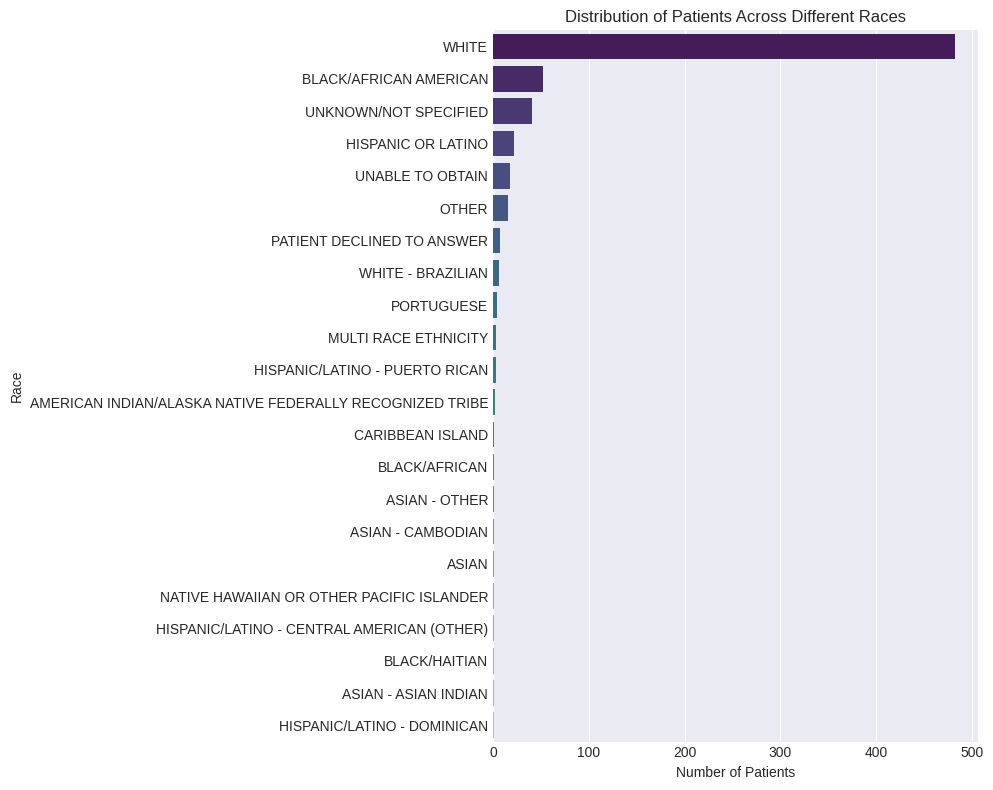

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. Plot for Class Imbalance Between Races (Count Plot) ---
print("\n--- Class Imbalance of Races ---")
plt.figure(figsize=(10, 8))
sns.countplot(data=df_demographics, y='race', order=df_demographics['race'].value_counts().index, palette='viridis')
plt.title('Distribution of Patients Across Different Races')
plt.xlabel('Number of Patients')
plt.ylabel('Race')
plt.tight_layout()
plt.show()


## Percentage of alive/dead per race


--- Mortality Proportions per Race ---


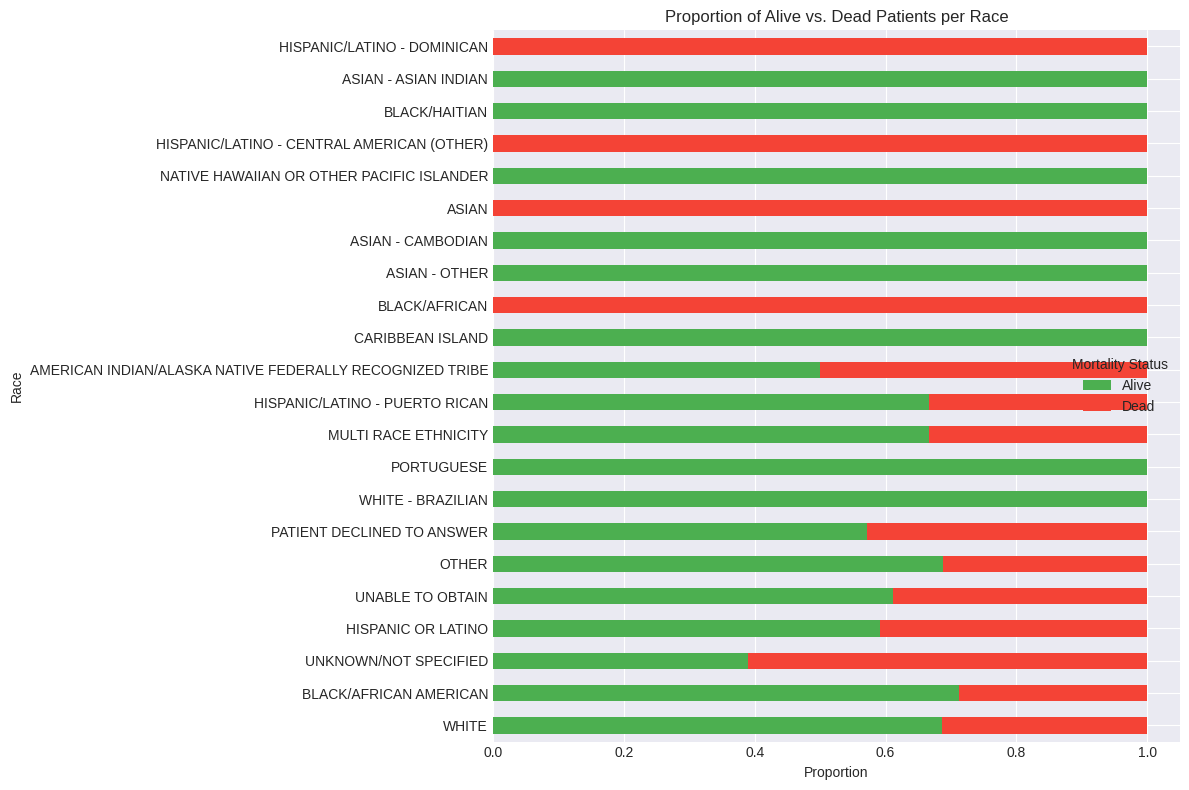

In [43]:

# --- 2. Plot for Percentages of Alive/Dead Persons per Race ---
print("\n--- Mortality Proportions per Race ---")

# Calculate proportions of mortality within each race
race_mortality_proportions = df_demographics.groupby('race')['mortality_flag'].value_counts(normalize=True).unstack().fillna(0)
race_mortality_proportions.columns = ['Alive_Prop', 'Dead_Prop']

# Sort by total count of race for consistent ordering with the first plot
race_order = df_demographics['race'].value_counts().index
race_mortality_proportions = race_mortality_proportions.reindex(race_order)

# Plotting the stacked bar chart
plt.figure(figsize=(12, 8))
race_mortality_proportions[['Alive_Prop', 'Dead_Prop']].plot(kind='barh', stacked=True, color=['#4CAF50', '#F44336'], ax=plt.gca())
plt.title('Proportion of Alive vs. Dead Patients per Race')
plt.xlabel('Proportion')
plt.ylabel('Race')
plt.legend(title='Mortality Status', labels=['Alive', 'Dead'])
plt.tight_layout()
plt.show()



--- EDA for Race ---


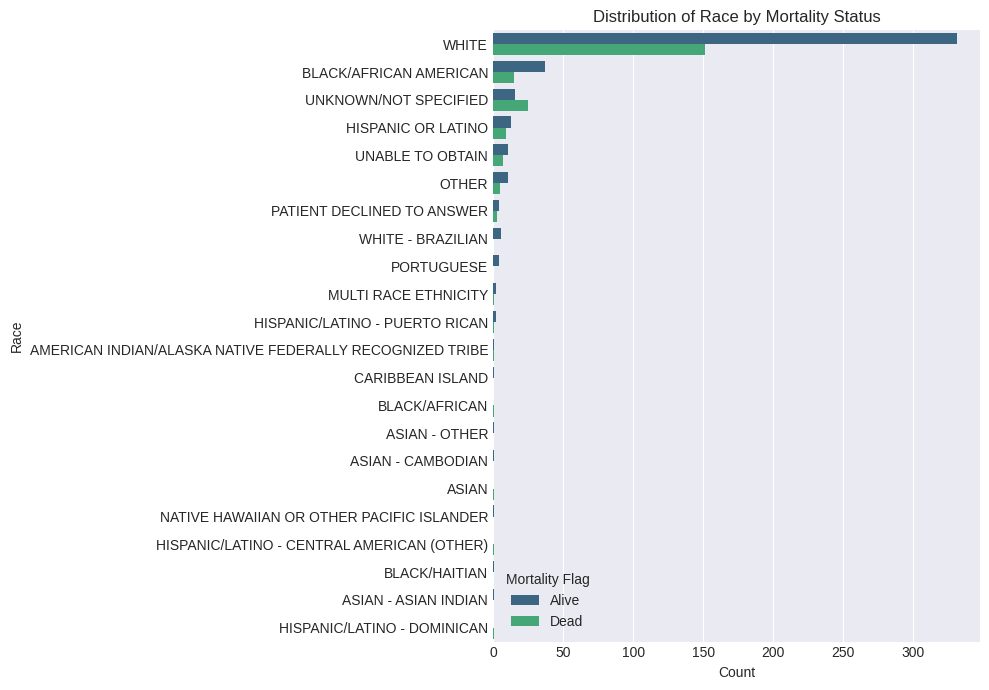

In [44]:
# --- 3. EDA for Race (Best visualization: Count plot with mortality) ---
print("\n--- EDA for Race ---")

# Count plot of Race, colored by mortality_flag
plt.figure(figsize=(10, 7))
sns.countplot(data=df_demographics, y='race', hue='mortality_flag', palette='viridis', order=df_demographics['race'].value_counts().index)
plt.title('Distribution of Race by Mortality Status')
plt.xlabel('Count')
plt.ylabel('Race')
plt.legend(title='Mortality Flag', labels=['Alive', 'Dead'])
plt.tight_layout()
plt.show()




In [45]:
# Optionally, to show proportions within each Race category
print("\nProportional Distribution of Mortality within each Race category:")
race_mortality_prop = df_demographics.groupby('race')['mortality_flag'].value_counts(normalize=True).unstack()
race_mortality_prop.columns = ['Alive_Prop', 'Dead_Prop']
display(race_mortality_prop)


Proportional Distribution of Mortality within each Race category:


,Alive_Prop,Dead_Prop
race,,
AMERICAN INDIAN/ALASKA NATIVE FEDERALLY RECOGNIZED TRIBE,0.500000,0.500000
ASIAN,NaN,1.000000
ASIAN - ASIAN INDIAN,1.000000,NaN
ASIAN - CAMBODIAN,1.000000,NaN
ASIAN - OTHER,1.000000,NaN
BLACK/AFRICAN,NaN,1.000000
BLACK/AFRICAN AMERICAN,0.711538,0.288462
BLACK/HAITIAN,1.000000,NaN
CARIBBEAN ISLAND,1.000000,NaN


# Extracting Cleaned csv data

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import pandas as pd

# Re-extract df_demographics from the current df (which does not contain subject_id or hadm_id)
df_demographics = df[['sex', 'age', 'race', 'insurance', 'mortality_flag']].copy()

# Create 'has_insurance' column as it was added in a previous step
df_demographics['has_insurance'] = df_demographics['insurance'].apply(lambda x: 'Insured' if x in ['Medicaid', 'Medicare', 'Private'] else 'No Insurance')

# Drop 'mortality_flag' and 'has_insurance' from df_demographics to avoid duplication during merge
df_demographics_no_mortality = df_demographics.drop(columns=['mortality_flag', 'has_insurance'])

# Merge df_demographics (without mortality_flag and has_insurance) and df_avg based on their index
# Both dataframes retain the original integer index from df (representing hospital admissions)
df_merged = pd.merge(
    df_demographics_no_mortality,
    df_avg,
    left_index=True,
    right_index=True,
    how='inner'
)

print("Shape of the merged DataFrame:", df_merged.shape)
print("First 5 rows of the merged DataFrame:")
display(df_merged.head())

# Save the merged DataFrame to a CSV file
output_filename = 'mimic_iii_merged_data_cleaned.csv'
df_merged.to_csv(output_filename, index=False)
print(f"\nMerged data saved to '{output_filename}'")

Shape of the merged DataFrame: (666, 56)
First 5 rows of the merged DataFrame:


,sex,age,race,insurance,myocardial_infarction,congestive_heart_failure,peripheral_vascular_disease,cerebrovascular_disease,dementia,chronic_pulmonary_disease,...,map_avg,sbp_avg,dbp_avg,heart_rate_avg,respiratory_rate_avg,o2_avg,weight_avg,height_avg,bmi_avg,mortality_flag
0,M,58,WHITE,Private,0,0,0,0,0,0,...,95.000000,146.0,70.0,60.366667,10.0,93.750000,96.600000,124.0,62.825182,0
1,M,49,WHITE,Medicare,0,0,0,0,1,0,...,111.000000,130.5,77.5,76.683333,12.0,96.200000,148.800000,NaN,NaN,0
2,M,47,WHITE,Medicare,0,0,0,0,0,0,...,91.000000,126.0,81.0,88.666667,17.0,95.333333,84.599998,NaN,NaN,0
3,M,55,WHITE,Medicare,0,1,0,0,0,0,...,69.333351,110.0,56.5,103.000000,30.0,94.333333,108.500000,NaN,NaN,0
4,F,52,UNKNOWN/NOT SPECIFIED,Private,0,0,0,0,0,0,...,68.333349,99.5,53.0,80.000000,13.5,98.000000,74.599998,NaN,NaN,1



Merged data saved to 'mimic_iii_merged_data_cleaned.csv'
